In [63]:
# Import necessary packages

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm, trange
import sctop as top # note: this uses sctop version 1.0.0
from itertools import combinations
from scipy.special import softmax
import matplotlib as mpl

# Settings for making nice plots

sns.set(context='talk', color_codes=True, palette='deep', style='whitegrid', font_scale=1.2,
        rc={'mathtext.fontset': 'cm', 'xtick.direction': 'in','ytick.direction': 'in',
            'figure.dpi':100, 'text.usetex':False}) #'axes.linewidth': 1.5

# 1. Load data
## Load gene expression profiles of alveolar types
The gene expression profiles of mouse early epithelial lung cells and adult alveolar cells will be used as the stored patterns $\xi^{\mu}_i$. They come from the Zepp et al. lung developmental atlas ([link](https://www.science.org/doi/10.1126/science.abc3172)) and mouse samples collected by the Kotton lab ([link](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSM6046035)).

In [3]:
mca, mca_metadata = top.load_basis('MC-KO')
lung_dev, lung_dev_metadata = top.load_basis('LD')

epithelial = lung_dev['Lung Early Epithelium Cell E12 LD21']
at1 = mca['Lung AT1 Cell WK6 KO22']
at2 = mca['Lung AT2 Cell WK6 KO22']

genes_in_common = np.intersect1d(epithelial.index, at1.index)
attractor_states = pd.concat([at1.loc[genes_in_common],
                              at2.loc[genes_in_common],
                              epithelial.loc[genes_in_common]
                             ], axis = 1)

attractor_states.columns = ['at1', 'at2', 'early epithelium']

N, P = attractor_states.shape

## Load list of marker genes
These marker genes are the same as those listed in the appendix of [Yampolskaya et al. 2023](https://doi.org/10.1242/dev.201873). In the simulations, they can be measured over the course of cell fate transitions to track gene expression dynamics.

In [4]:
type_signatures = pd.read_csv('./herriges_cell_type_signatures.csv')
AT1_signature = type_signatures.loc[:, 'Mouse_AT1'].dropna()

AT1_signature = np.intersect1d(genes_in_common, AT1_signature)

In [5]:
# Helper function for displaying color bar of gene activity
from matplotlib.cm import ScalarMappable

def create_colorbar(data, label, colormap='rocket_r', **kwargs):
#     ax = ax or plt.gca()
    
    cmap = plt.get_cmap(colormap)
    scalarmap = ScalarMappable(norm=plt.Normalize(min(data), max(data)),
                               cmap=cmap)
    scalarmap.set_array([])
    plt.colorbar(scalarmap, label=label, **kwargs)
    
    return cmap

# 2. Define functions and classes for simulating attractor networks

## Define gradient functions and attractors for each landscape

In [6]:
# Define potentials by their gradients and the approximate positions of their attractors

def triple_cusp_grad(x, y, params):
    grad_x = 6*x**5 - 4*x**3 + 2*x + 4*x*y + params['f']
    grad_y = 16*y**3 - 2*y + 2*x**2 + params['k']    
    return grad_x, grad_y

def het_flip_grad(x, y, params):
    grad_x = 4*x**3 + 4*x*y + params['f'] 
    grad_y = 4*y**3 - 3*y**2 + 2*x**2 - 2*y + params['k'] 
    return grad_x, grad_y

def double_cusp_grad(x, y, params):
    grad_x = 4*x**3 + 8*x*y + params['f']
    grad_y = 4*y**3 - 3*y**2 + 4*x**2 + 2*y - params['k']
    return grad_x, grad_y

triple_cusp_coords = {'y0': 0.345, 
                     'x1': 0.838,
                     'y1': -0.537
                    }

# heteroclinic flip:
het_flip_coords = {'y0': 0.82,
                    'x1': 0.964,
                    'y1': -0.877
                   }

# double cusp:
double_cusp_coords = {'y0': 0.085,
                      'x1': 1.349,
                      'y1': -0.911
                      }

## Define matrices for converting between $(\tilde{x}, \tilde{y})$ coordinates and $(m_0, m_1, m_2)$

In [7]:
# We have some potential of the form V(x, y)
# To calculate V(m), we project between m-space to xy-space
# To find the matrix that transforms between x and m, we need
# translations, rotations, and scaling in 4 dimensions

# In other words, this takes (0, y0) to (0, 0, 1)
# (x1, y1) -> (0, 1, 0), and (-x1, y1) -> (1, 0, 0)

# First we define matrix M, which moves the 2-dimensional triangle vertices
# to the vertices of a simplex on three axes

T = np.array([[1, 0, 0, -1],
              [0, 1, 0, 0],
              [0, 0, 1, 0],
              [0, 0, 0, 1]])

Tinv = np.array([[1, 0, 0, 1],
                 [0, 1, 0, 0],
                 [0, 0, 1, 0],
                 [0, 0, 0, 1]])

X = np.array([[1, 0, 0, 0],
              [0, 0, -1, 0],
              [0, 1, 0, 0],
              [0, 0, 0, 1]])

Xinv = np.array([[1, 0, 0, 0],
                 [0, 0, 1, 0],
                 [0, -1, 0, 0],
                 [0, 0, 0, 1]])

sq2 = np.sqrt(2) / 2
psi = np.arcsin(np.sqrt(2/3))

Y = np.array([[sq2, 0, sq2, 0],
              [0, 1, 0, 0],
              [-sq2, 0, sq2, 0],
              [0, 0, 0, 1]])

Yinv = np.array([[sq2, 0, -sq2, 0],
                 [0, 1, 0, 0],
                 [sq2, 0, sq2, 0],
                 [0, 0, 0, 1]])

Z = np.array([[np.cos(psi), -np.sin(psi), 0, 0],
              [np.sin(psi), np.cos(psi), 0, 0],
              [0, 0, 1, 0],
              [0, 0, 0, 1]])

M = np.dot(Tinv, np.dot(Xinv, np.dot(Yinv, np.dot(Z, np.dot(Y, np.dot(X, T))))))

# Make adjustments for the positions of the attractors in xy-space
def generate_x_to_m_matrix(y0, x1, y1):
    S = np.array([
        [np.sqrt(2)/(2*x1), 0, 0, 0],
        [0, np.sqrt(3/2)/(y0 - y1), 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ])

    T1 = np.array([
        [1, 0, 0, 0],
        [0, 1, 0, -np.sqrt(2)/2 - (y1 * np.sqrt(3/2))/(y0 - y1)],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ])

    theta = (3 * np.pi)/4
    R1 = np.array([
        [np.cos(theta), -np.sin(theta), 0, 0],
        [np.sin(theta), np.cos(theta), 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ])
    
    return np.dot(M, np.dot(R1, np.dot(T1, S)))
    
def initialize_attractor_vectors(y0, x1, y1):
    attractor0 = np.array([[0],
                           [y0],
                           [0],
                           [1]
                        ])

    attractor1 = np.array([
        [x1],
        [y1],
        [0],
        [1]
    ])

    attractor2 = np.array([
        [-x1],
        [y1],
        [0],
        [1]
    ])

    return (attractor0, attractor1, attractor2)

## Define AttractorNetwork class for simulating landscape-driven Hopfield dynamics

In [8]:
class AttractorNetwork:
    """
    A class that simulates an attractor-based dynamical system with an evolving energy landscape.
    The system evolves toward stored attractor states under the influence of external gradients.
    """

    def __init__(self, dynamics_args, landscape_args):
        """
        Initialize the attractor network.

        Parameters:
        - dynamics_args: Dictionary containing 'stored_states' (matrix of gene expression profiles) and 'initial_state':
        
            dynamics_args = {
                'stored_states': attractor states stored as rows in a 2D array,
                'initial_state': the starting gene expression state (1D array)
            }
        
        - landscape_args: Dictionary containing 'start_params', 'attractor_coords', and 'gradients':
        
            landscape_args = {
                'start_params': dict of initial parameters for the energy landscape,
                'attractor_coords': coordinates for attractor projections in x-y space,
                'gradients': function returning gradients of the landscape w.r.t. x and y
            }
        
        """
        
        self.attractors = dynamics_args['stored_states'].copy()
        self.state = dynamics_args['initial_state'].copy()

        self.params = landscape_args['start_params'].copy()
        self.start_params = landscape_args['start_params']
        
        self.N = len(self.state)  # Number of elements in the state vector.
        self.temperature = 1 / (2 * self.N) # low temperature, so that there's not too much random jumping

        # Calculate the correlation matrix and its inverse.
        self.corr = (1 / self.N) * self.attractors.dot(self.attractors.T)
        self.inv_corr = np.linalg.inv(self.corr)

        # Unpack the attractor coordinates.
        self.x0, self.y0 = landscape_args['attractor_coords'][0]
        self.x1, self.y1 = landscape_args['attractor_coords'][1]
        
        self.x_hat = np.array([1, 0, 0, 0])
        self.y_hat = np.array([0, 1, 0, 0])
        
        x_to_m = generate_x_to_m_matrix(self.y0, self.x1, self.y1)
        self.m_to_x = np.linalg.inv(x_to_m)
        
        self.hx = np.dot(self.x_hat, self.m_to_x)
        self.hy = np.dot(self.y_hat, self.m_to_x)
        
        self.gradients = landscape_args['gradients']

        self.rng = np.random.default_rng()
        
    def dynamics(self):
        """
        Compute the change in the system's state based on attractor dynamics
        and the gradient of the external potential landscape.
        
        Returns:
        - A vector representing the change in state.
        """
        
        m_up = (1/self.N)*self.attractors.dot(self.state) # upper index/contravariant
        m_low = self.inv_corr.dot(m_up) # lower index/covariant
        
        m_low_4d = np.array([*m_low, 1])
        
        x = np.dot(self.hx, m_low_4d)
        y = np.dot(self.hy, m_low_4d)
        
        inv_corr_4d = np.vstack((self.inv_corr, np.array([0, 0, 0])))
        inv_corr_4d = np.hstack((inv_corr_4d, np.array([0, 0, 0, 1]).reshape(-1, 1)))
        
        x_chain = np.dot(self.hx, inv_corr_4d)
        y_chain = np.dot(self.hy, inv_corr_4d)
        
        grad_x, grad_y = self.gradients(x, y, self.params)
        
        potential_grad = grad_x*x_chain + grad_y*y_chain
        potential_grad = potential_grad[:3]
        
        gradient_scale = 10 # adjustment factor to increase effect of gradient

        attraction = self.attractors.T.dot(
            softmax((1/self.temperature)*(m_low - gradient_scale*potential_grad))
        )
        
        return attraction - self.state

        
    def update(self):
        """
        Perform a single update of the network state using synchronous or asynchronous dynamics.
        """
        
        # "asynchronous updates": randomly choose which genes to update each time
        timing_scale = 10
        asynch = self.rng.binomial(1, 1/timing_scale, size=N) # allow 1 in __ genes to update at each step
        self.state += asynch*self.dynamics()/20
        
        # synchronous updates: all genes update simultaneously
#         self.state += self.dynamics()/20

    def increment_param(self, t, param, signal_bounds, finish_params):
        """
        Increment a specific bifurcation parameter gradually between start and end times.

        Parameters:
        - t: Current simulation time.
        - param: Parameter name to increment (e.g., 'f', 'k').
        - signal_bounds: Dict with 'start' and 'end' times for each parameter.
        - finish_params: Dict of final target values for parameters.
        """
        
        if (t > signal_bounds['start'][param]) and (t < signal_bounds['end'][param]):
            self.params[param] += (finish_params[param] - self.start_params[param])/(signal_bounds['end'][param] - signal_bounds['start'][param])

    def simulate(self, total_time, signal_bounds, finish_params, recorded_genes = None, add_noise = False):
        """
        Run a full simulation of the network over time, tracking magnetizations and optionally individual genes.

        Parameters:
        - total_time: Duration of the simulation.
        - signal_bounds: Dict specifying start/end times for each parameter change.
        - finish_params: Dict of final values for changing parameters.
        - recorded_genes: List of gene names (indices) to record over time.
        - add_noise: If True, adds dropout and Gaussian noise to measurements.

        Returns:
        - A pandas DataFrame containing time series of order parameters, magnetizations, and recorded genes.
        """

        magnetizations = []

        gene_dict = {}
        if recorded_genes is not None:
            for gene in recorded_genes:
                gene_dict[gene] = []

        t = 0
        time_interval = 1 # in minutes        
        while t < total_time:
            # Choose which parameters to increment
            self.increment_param(t, 'f', signal_bounds, finish_params)
            self.increment_param(t, 'k', signal_bounds, finish_params)
            
            if add_noise: # this just adds noise to the observations, not to the system
                detection_rate = 0.4
                dropout = self.rng.binomial(1, detection_rate, size=N)
                zero_indices = np.where(dropout == 0)[0]
                
                dropout_state = self.state.T.copy()
                dropout_state.iloc[zero_indices] = -1
                
                noise = self.rng.standard_normal(size=N)
                
                magnetizations += [(1/N)*self.attractors.dot(dropout_state + noise)]
                
            else:
                magnetizations += [(1/N)*self.attractors.dot(self.state.T)]
                
            if recorded_genes is not None:
                for gene in recorded_genes:
                    gene_dict[gene] += [self.state.loc[gene]]
            
            self.update()
            t += time_interval
                    
        magnetizations = pd.DataFrame(magnetizations)
        if len(magnetizations.columns[0]) < 2:
            magnetizations = pd.DataFrame(magnetizations, columns = ['m{}'.format(index) for index in range(self.attractors.shape[0])])
        order_params = self.inv_corr.dot(magnetizations.T)
        
        output_df = pd.concat([pd.DataFrame(order_params, index = magnetizations.columns).T, magnetizations, pd.DataFrame(gene_dict)], axis=1)

        if len(magnetizations.columns[0]) < 2:
            output_df = pd.concat([pd.DataFrame(order_params, index = ['a{}'.format(index) for index in range(self.attractors.shape[0])]).T,
                                magnetizations, pd.DataFrame(gene_dict)], axis=1)
        return output_df

# Triple cusp simulations

In [9]:
n_trials = 1
output_list = []
gene_list = []
signature_list = []
rng = np.random.default_rng()

total_time = 1000

landscape_args = {'start_params': {'f': 0, 'k': 0},
                  'attractor_coords': [[0, triple_cusp_coords['y0']], [triple_cusp_coords['x1'], triple_cusp_coords['y1']]],
                  'gradients': triple_cusp_grad,
                 }

dynamics_args = {'stored_states': attractor_states.T,
                 'rhos': [0, 10]
                }

for trial in trange(n_trials):
    # generate new initial coordinates for each trial
    dynamics_args['initial_state'] =  attractor_states['early epithelium'] + rng.standard_normal(size=N)

    attractor_network = AttractorNetwork(dynamics_args, landscape_args)
    
    simulation_args = {'total_time': total_time,
                        'signal_bounds': {'start': {'f': 700, 'k': 100},
                                          'end':   {'f': 900, 'k': 300}},
                        'finish_params': {'f': rng.choice([-0.3, 0.3]), 'k': 0.3},
                        'recorded_genes': ['Sftpc', 'Aqp5'],
                        # 'recorded_genes': ['Sftpc', *AT1_signature],
                        'add_noise': False
                        }
    
    output = attractor_network.simulate(**simulation_args)
    # AT1_signatures = output[AT1_signature].mean(axis=1)
    output_list += [output.iloc[:, :3]]
    gene_list += [output[['Sftpc','Aqp5']]]
    # signature_list += [AT1_signatures]

all_output = pd.concat(output_list, axis=0)
all_genes = pd.concat(gene_list, axis=0)
# signature = pd.concat(signature_list, axis=0)

100%|██████████| 1/1 [00:02<00:00,  2.20s/it]


In [11]:
# Randomly select cells to exclude from plotting
# This is meant to simulate the fact that we don't see every cell at every step of differentiation

rng = np.random.default_rng()
drop_index_rv = rng.binomial(n=1, p=0.8, size=n_trials*total_time)
remaining_indices = np.where(drop_index_rv == 0)[0]
dropped_data = all_output.iloc[remaining_indices]

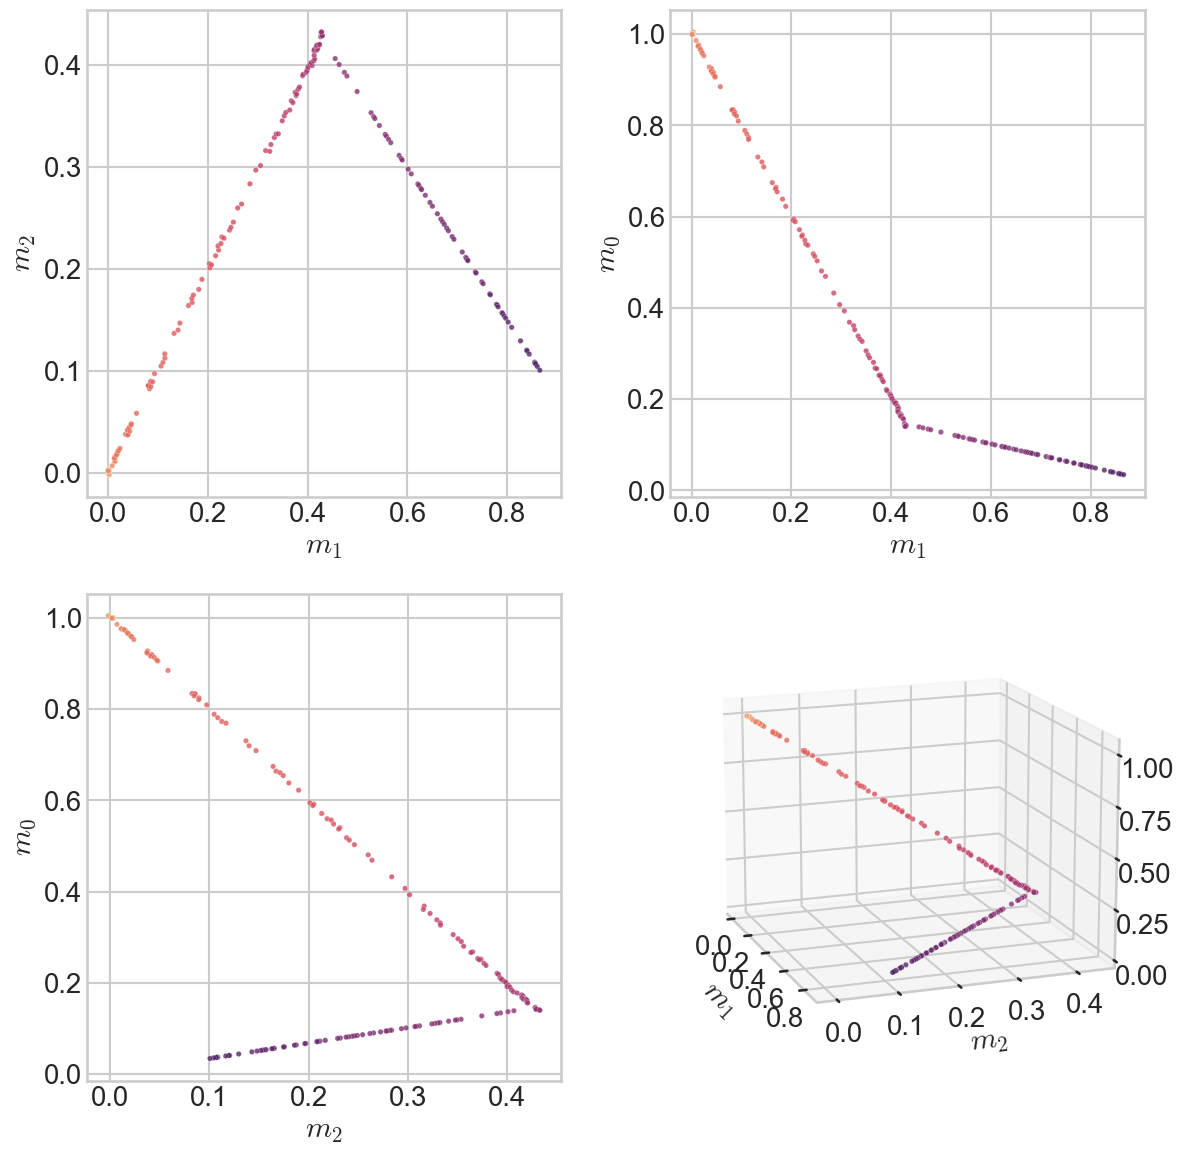

In [12]:
fig = plt.figure(figsize=(12,12))

label_dict = {'at1': '$m_1$',
              'at2': '$m_2$',
              'early epithelium': '$m_0$'
             }

kwargs = {"c": dropped_data.index,
          "cmap": sns.color_palette("flare", as_cmap=True),
          "alpha": 0.8,
          "s": 15,
          "edgecolors": 'white',
          "linewidth": 0.2
         }

for subplot_index, pair in enumerate(combinations(['at1','at2','early epithelium'], 2)):
    ax = fig.add_subplot(2, 2, subplot_index+1)

    ax.scatter(dropped_data[pair[0]], dropped_data[pair[1]], **kwargs)
    
    ax.set_xlabel(label_dict[pair[0]])
    ax.set_ylabel(label_dict[pair[1]])
               
view = [15, -20]
ax = fig.add_subplot(2, 2, 4, projection='3d')

ax.scatter(dropped_data['at1'], dropped_data['at2'], dropped_data['early epithelium'],**kwargs)
    
ax.view_init(elev=view[0], azim=view[1])

ax.set_xlabel('$m_1$', labelpad=10)
ax.set_ylabel('$m_2$', labelpad=10)
ax.set_zlabel('$m_0$', labelpad=10)
               
plt.tight_layout()

# plt.savefig("/project/biophys/scTOP analyses/Hopfield landscape paper/figs/triple cusp projections (colored by time).png", bbox_inches = "tight")
    
plt.show()

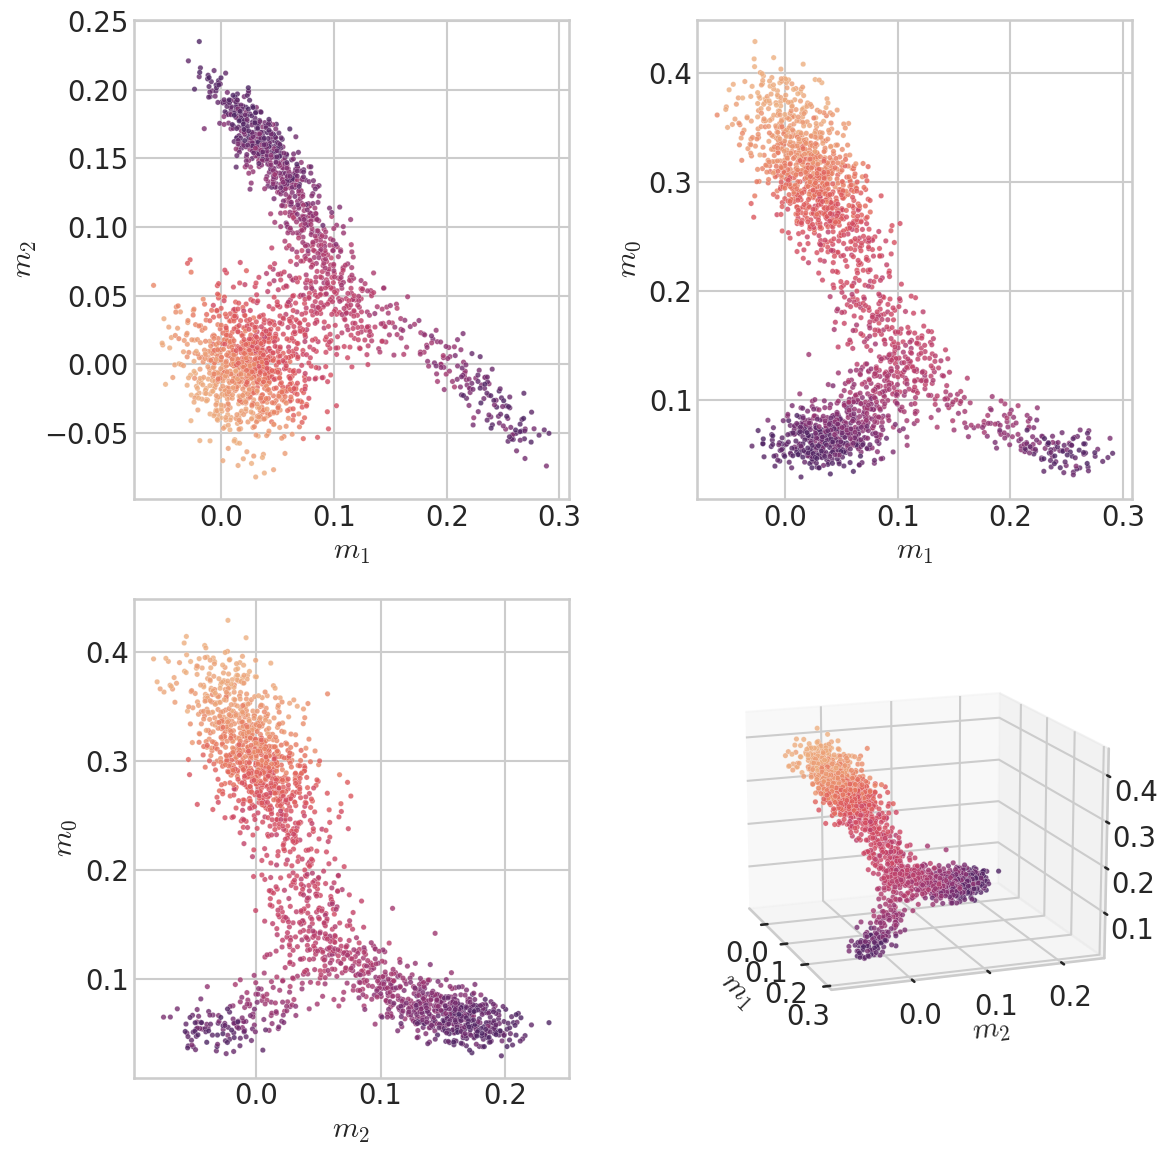

In [212]:
fig = plt.figure(figsize=(12,12))

label_dict = {'at1': '$m_1$',
              'at2': '$m_2$',
              'early epithelium': '$m_0$'
             }

kwargs = {"c": dropped_data.index,
          "cmap": sns.color_palette("flare", as_cmap=True),
          "alpha": 0.8,
          "s": 15,
          "edgecolors": 'white',
          "linewidth": 0.2
         }

for subplot_index, pair in enumerate(combinations(['at1','at2','early epithelium'], 2)):
    ax = fig.add_subplot(2, 2, subplot_index+1)

    ax.scatter(dropped_data[pair[0]], dropped_data[pair[1]], **kwargs)
    
    ax.set_xlabel(label_dict[pair[0]])
    ax.set_ylabel(label_dict[pair[1]])
               
view = [15, -20]
ax = fig.add_subplot(2, 2, 4, projection='3d')

ax.scatter(dropped_data['at1'], dropped_data['at2'], dropped_data['early epithelium'],**kwargs)
    
ax.view_init(elev=view[0], azim=view[1])

ax.set_xlabel('$m_1$', labelpad=10)
ax.set_ylabel('$m_2$', labelpad=10)
ax.set_zlabel('$m_0$', labelpad=10)
               
plt.tight_layout()

plt.savefig("/project/biophys/scTOP analyses/Hopfield landscape paper/figs/triple cusp projections (colored by time).png", bbox_inches = "tight")
    
plt.show()

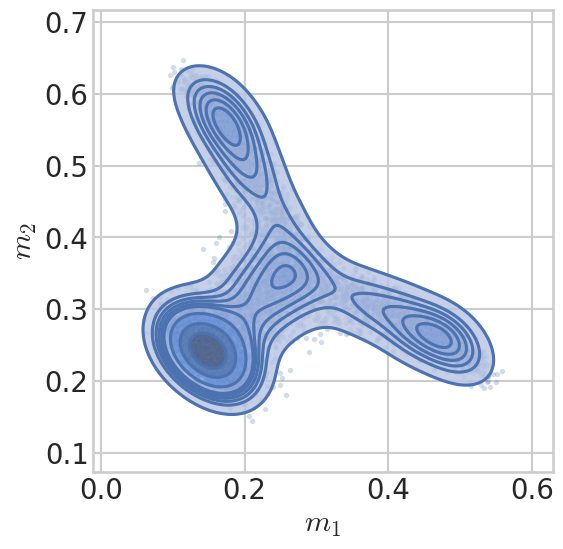

In [248]:
current_data = all_output

type1, type2 = 'at1', 'at2', 
fig = plt.figure(figsize=(6,6))
sns.scatterplot(x = current_data[type1], 
                y = current_data[type2],
                color = sns.color_palette()[0],
                alpha = 0.25,
                s = 15
               )

sns.kdeplot(x = current_data[type1], 
            y = current_data[type2],
            fill=True,
            alpha=0.8,
#             color='tab:blue'
           )

sns.kdeplot(x = current_data[type1], 
            y = current_data[type2],
#             color='tab:blue'
           )

plt.gca().set_aspect('equal')

plt.tight_layout()
plt.xlabel('$m_1$')
plt.ylabel('$m_2$')


plt.savefig("/project/biophys/scTOP analyses/Hopfield landscape paper/figs/triple cusp projections (kdeplot).png", bbox_inches = "tight")

plt.show()

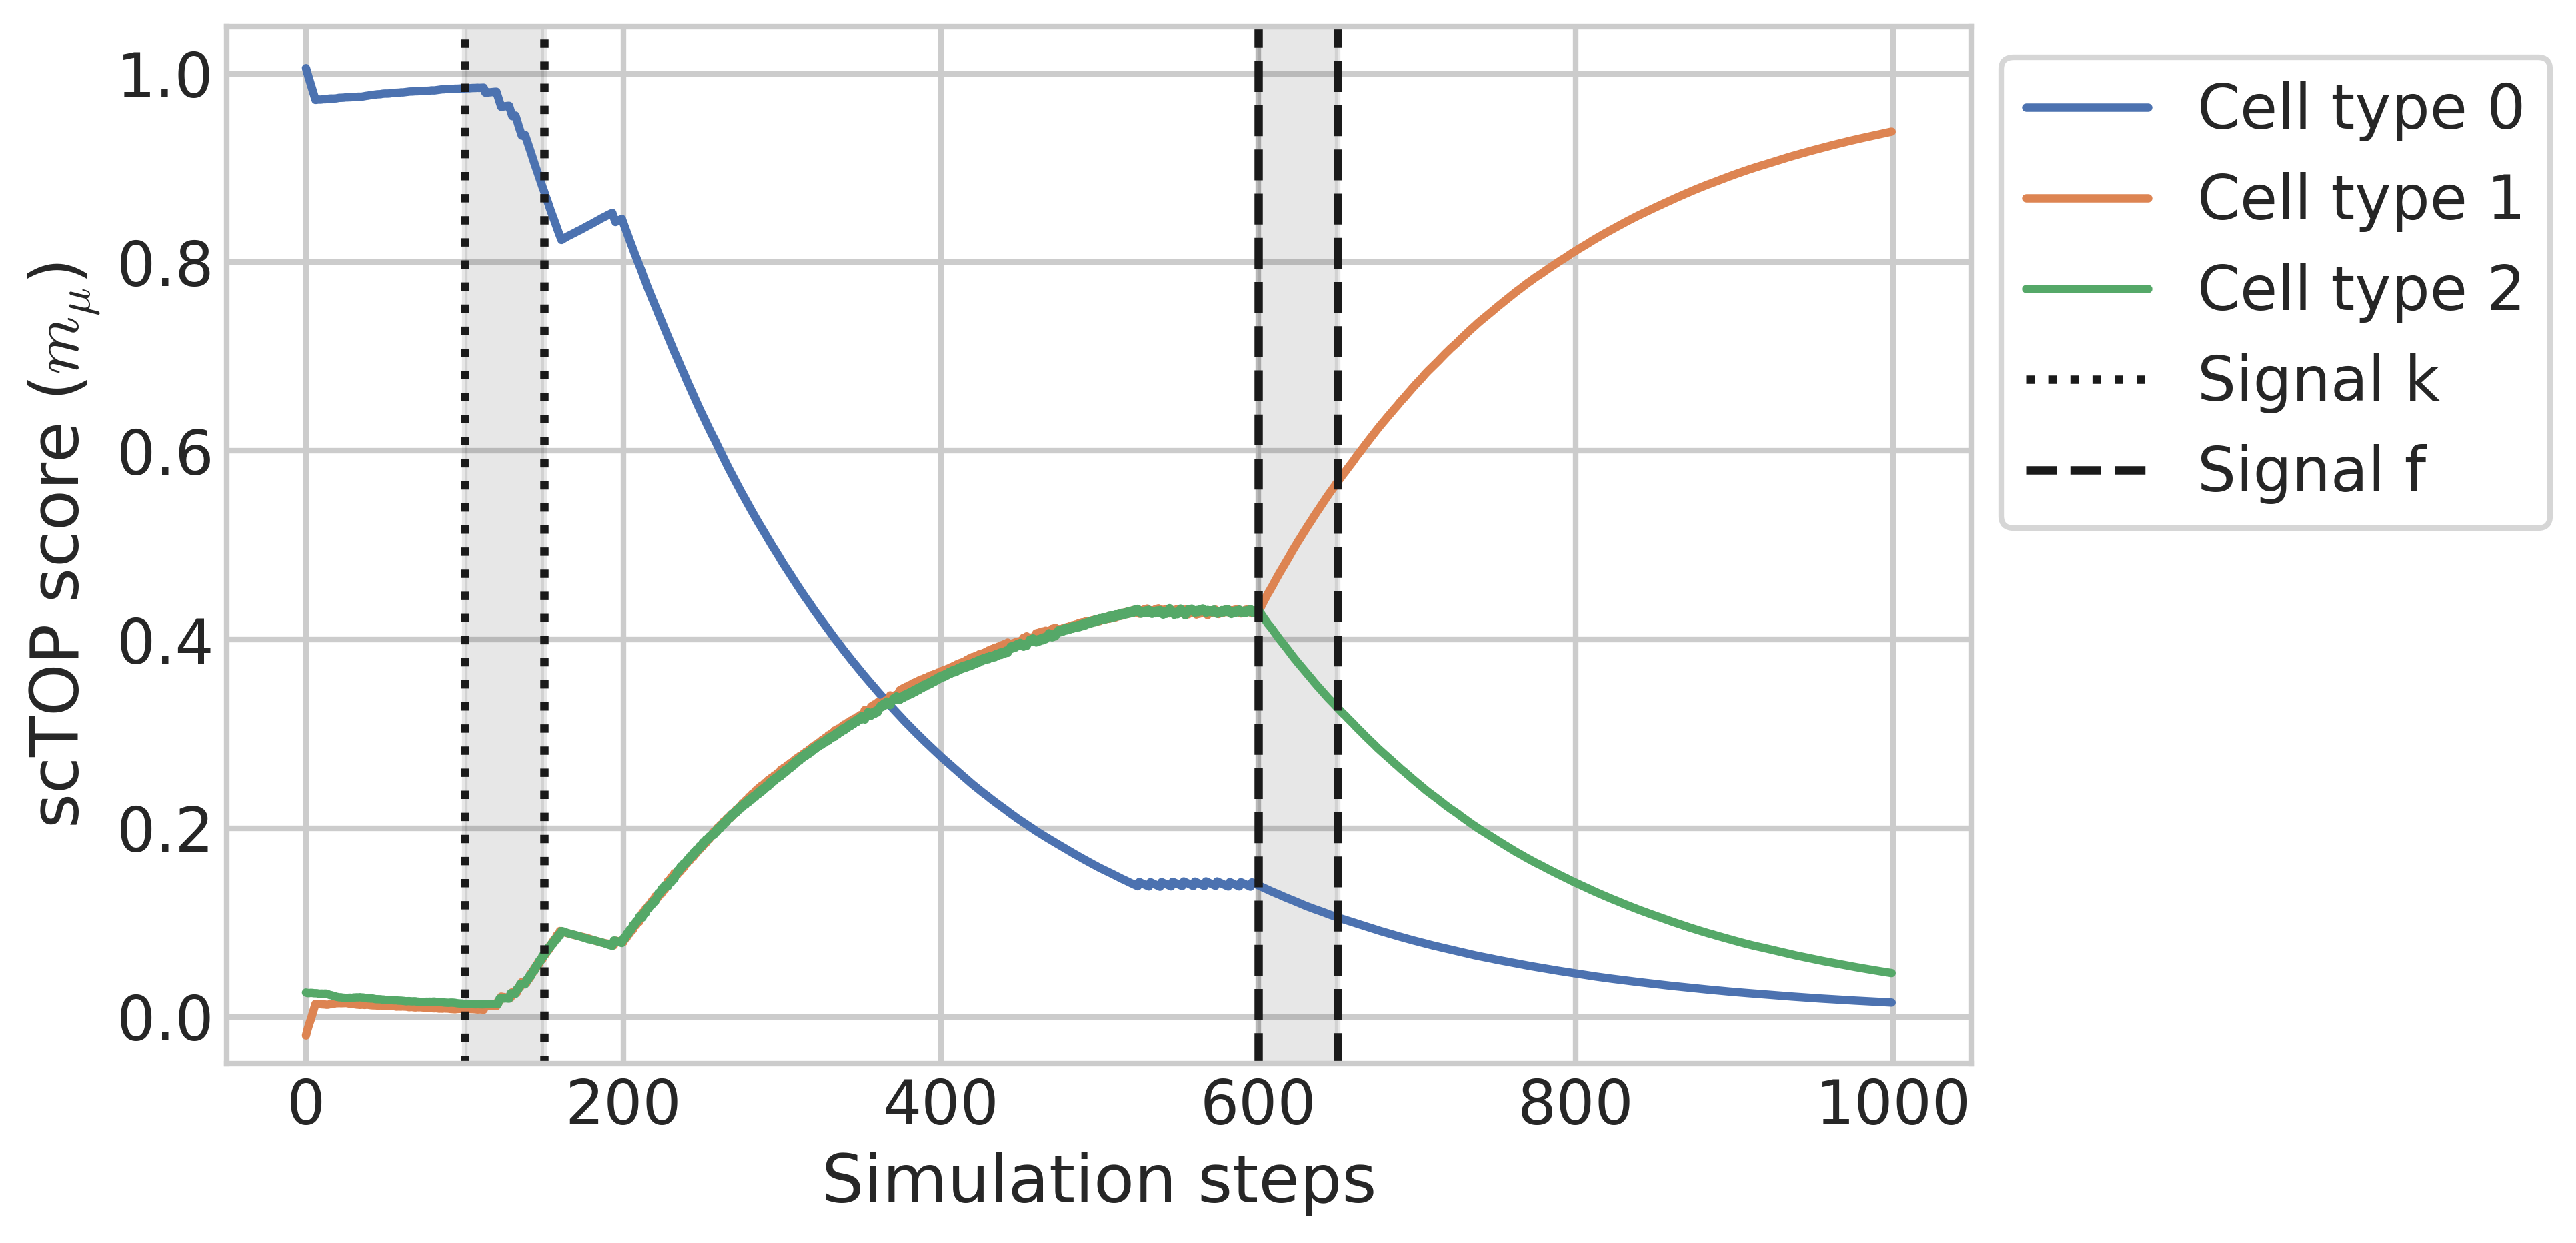

In [87]:
fig = plt.figure(figsize=(10,5))

separated_trials = pd.concat([all_output.iloc[0:total_time] for i in range(n_trials)], axis=1)

at1 = separated_trials['at1'].mean(axis=1)
at2 = separated_trials['at2'].mean(axis=1)
epithelium = separated_trials['early epithelium'].mean(axis=1)

plt.plot(range(total_time), epithelium, label='Cell type 0')
plt.plot(range(total_time), at1, label='Cell type 1')
plt.plot(range(total_time), at2, label='Cell type 2')

plt.axvline(x=simulation_args['signal_bounds']['start']['k'], label='Signal k', color='k', linestyle=':')
plt.axvline(x=simulation_args['signal_bounds']['end']['k'], color='k', linestyle=':')
plt.axvspan(simulation_args['signal_bounds']['start']['k'], simulation_args['signal_bounds']['end']['k'], alpha=0.1, color='k')

plt.axvline(x=simulation_args['signal_bounds']['start']['f'], label='Signal f', color='k', linestyle='--')
plt.axvline(x=simulation_args['signal_bounds']['end']['f'], color='k', linestyle='--')
plt.axvspan(simulation_args['signal_bounds']['start']['f'], simulation_args['signal_bounds']['end']['f'], alpha=0.1, color='k')

plt.legend(bbox_to_anchor=(1,1), loc="upper left",)


plt.ylim([-0.05, 1.05])

plt.xlabel('Simulation steps')
plt.ylabel('scTOP score ($m_{\mu}$)')


plt.tight_layout()

plt.savefig("/project/biophys/scTOP analyses/Hopfield landscape paper/figs/triple cusp 1 in 9 update (avg over 10 trials).png", bbox_inches = "tight")
plt.show()

/scratch/282988.1.ood/ipykernel_1571928/4206457691.py:37: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


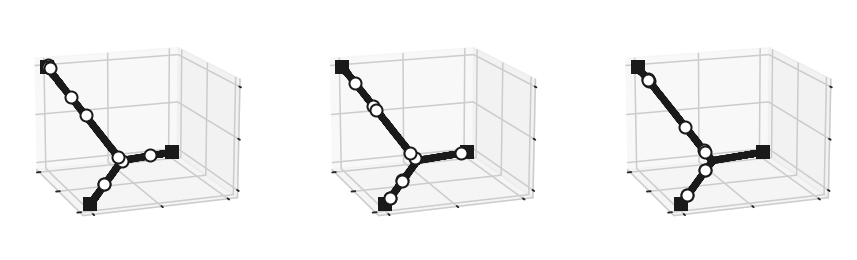

In [10]:
# Without noise

time_points = [0, 220, 400]
num_plots = len(time_points)
fig = plt.figure(figsize=(num_plots*5,5))

for i, time_point in enumerate(time_points):
    ax = fig.add_subplot(1, num_plots, i+1, projection='3d')

    this_plot = pd.concat([all_output.iloc[time_point + i*750] for i in range(n_trials)], axis=1)
    ax.plot(this_plot.loc['at1'], 
               this_plot.loc['at2'], 
               this_plot.loc['early epithelium'], 'o',
               markerfacecolor='white', markeredgecolor='k', markeredgewidth=2, markersize=12, zorder=10)
    
    ax.plot(all_output['at1'], 
               all_output['at2'], 
               all_output['early epithelium'], 'o',
               alpha=0.35, color='k', markersize=5, zorder = 2)
    
    ax.plot([1, 0, 0], 
           [0, 1, 0], 
           [0, 0, 1], 's',
           color='k', markeredgewidth=2, markersize=12, zorder=1)

    bounds = [-0.05, 1.05]
    ax.set_xlim(bounds)
    ax.set_ylim(bounds)
    ax.set_zlim(bounds)
    
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])

    ax.view_init(elev=15, azim=-20)

plt.tight_layout()

# plt.savefig("/project/biophys/scTOP analyses/Hopfield landscape paper/figs/triple cusp fig 2.png", bbox_inches = "tight")
plt.show()

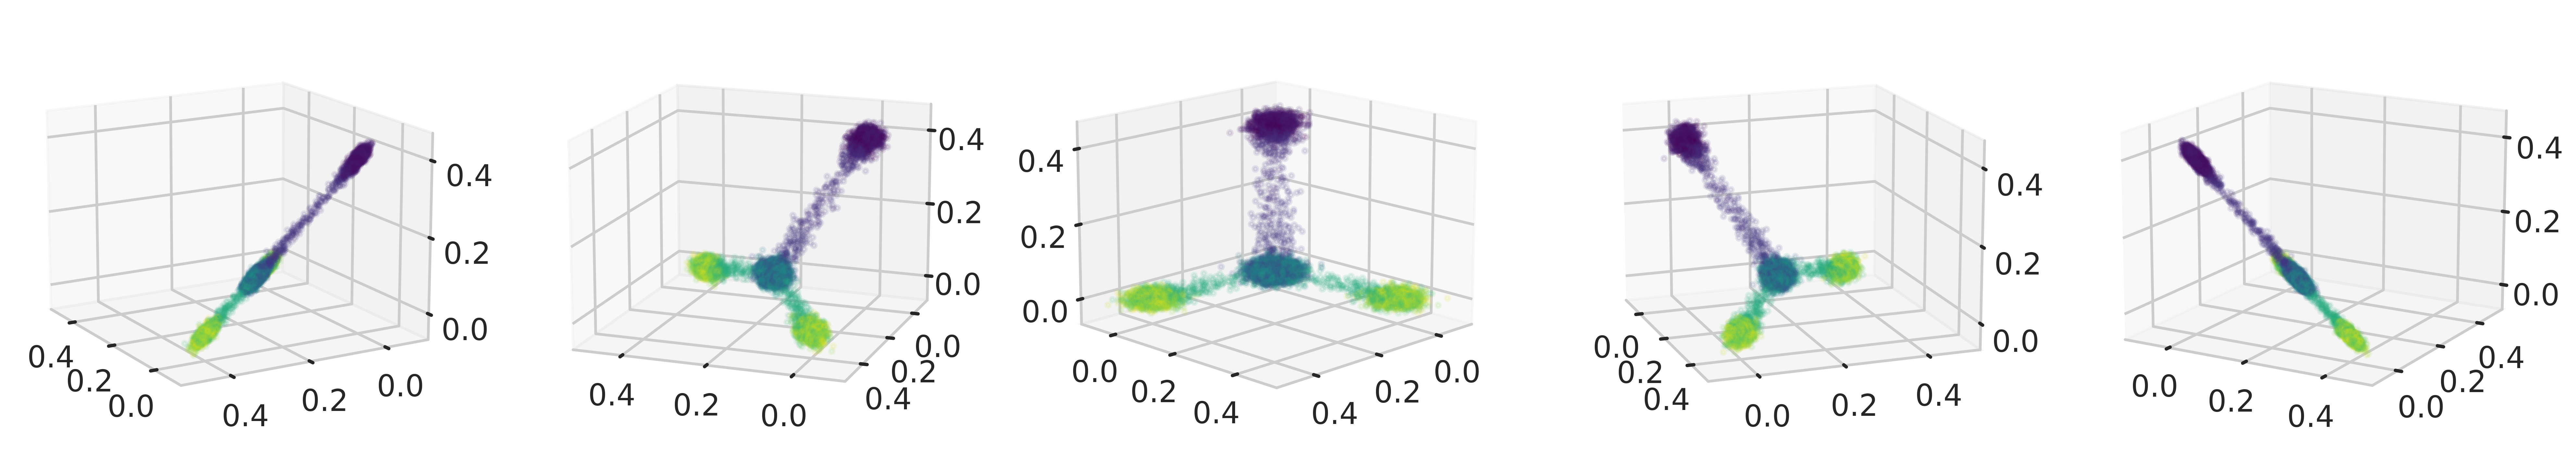

In [38]:
fig = plt.figure(figsize=(25,5))

views = [[15, 150], [15, 110], [15, 45], [15, -20], [15, -60]]
num_views = len(views)

for subplot_index, view in enumerate(views):
    ax = fig.add_subplot(1, num_views, subplot_index+1, projection='3d')

    ax.scatter(all_output['at1'], all_output['at2'], all_output['early epithelium'],
               alpha=0.1, c=all_output.index, s = 7, cmap='viridis')

#     ax.set_xlabel("AT1", labelpad=10)
#     ax.set_ylabel("AT2", labelpad=10)
#     ax.set_zlabel("Early epithelium", labelpad=10)
    
    ax.view_init(elev=view[0], azim=view[1])

plt.savefig("/project/biophys/scTOP analyses/Hopfield landscape paper/figs/triple cusp 3d noise.png", bbox_inches = "tight")

plt.show()

/scratch/245703.1.ood/ipykernel_1353962/2871769465.py:22: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar()


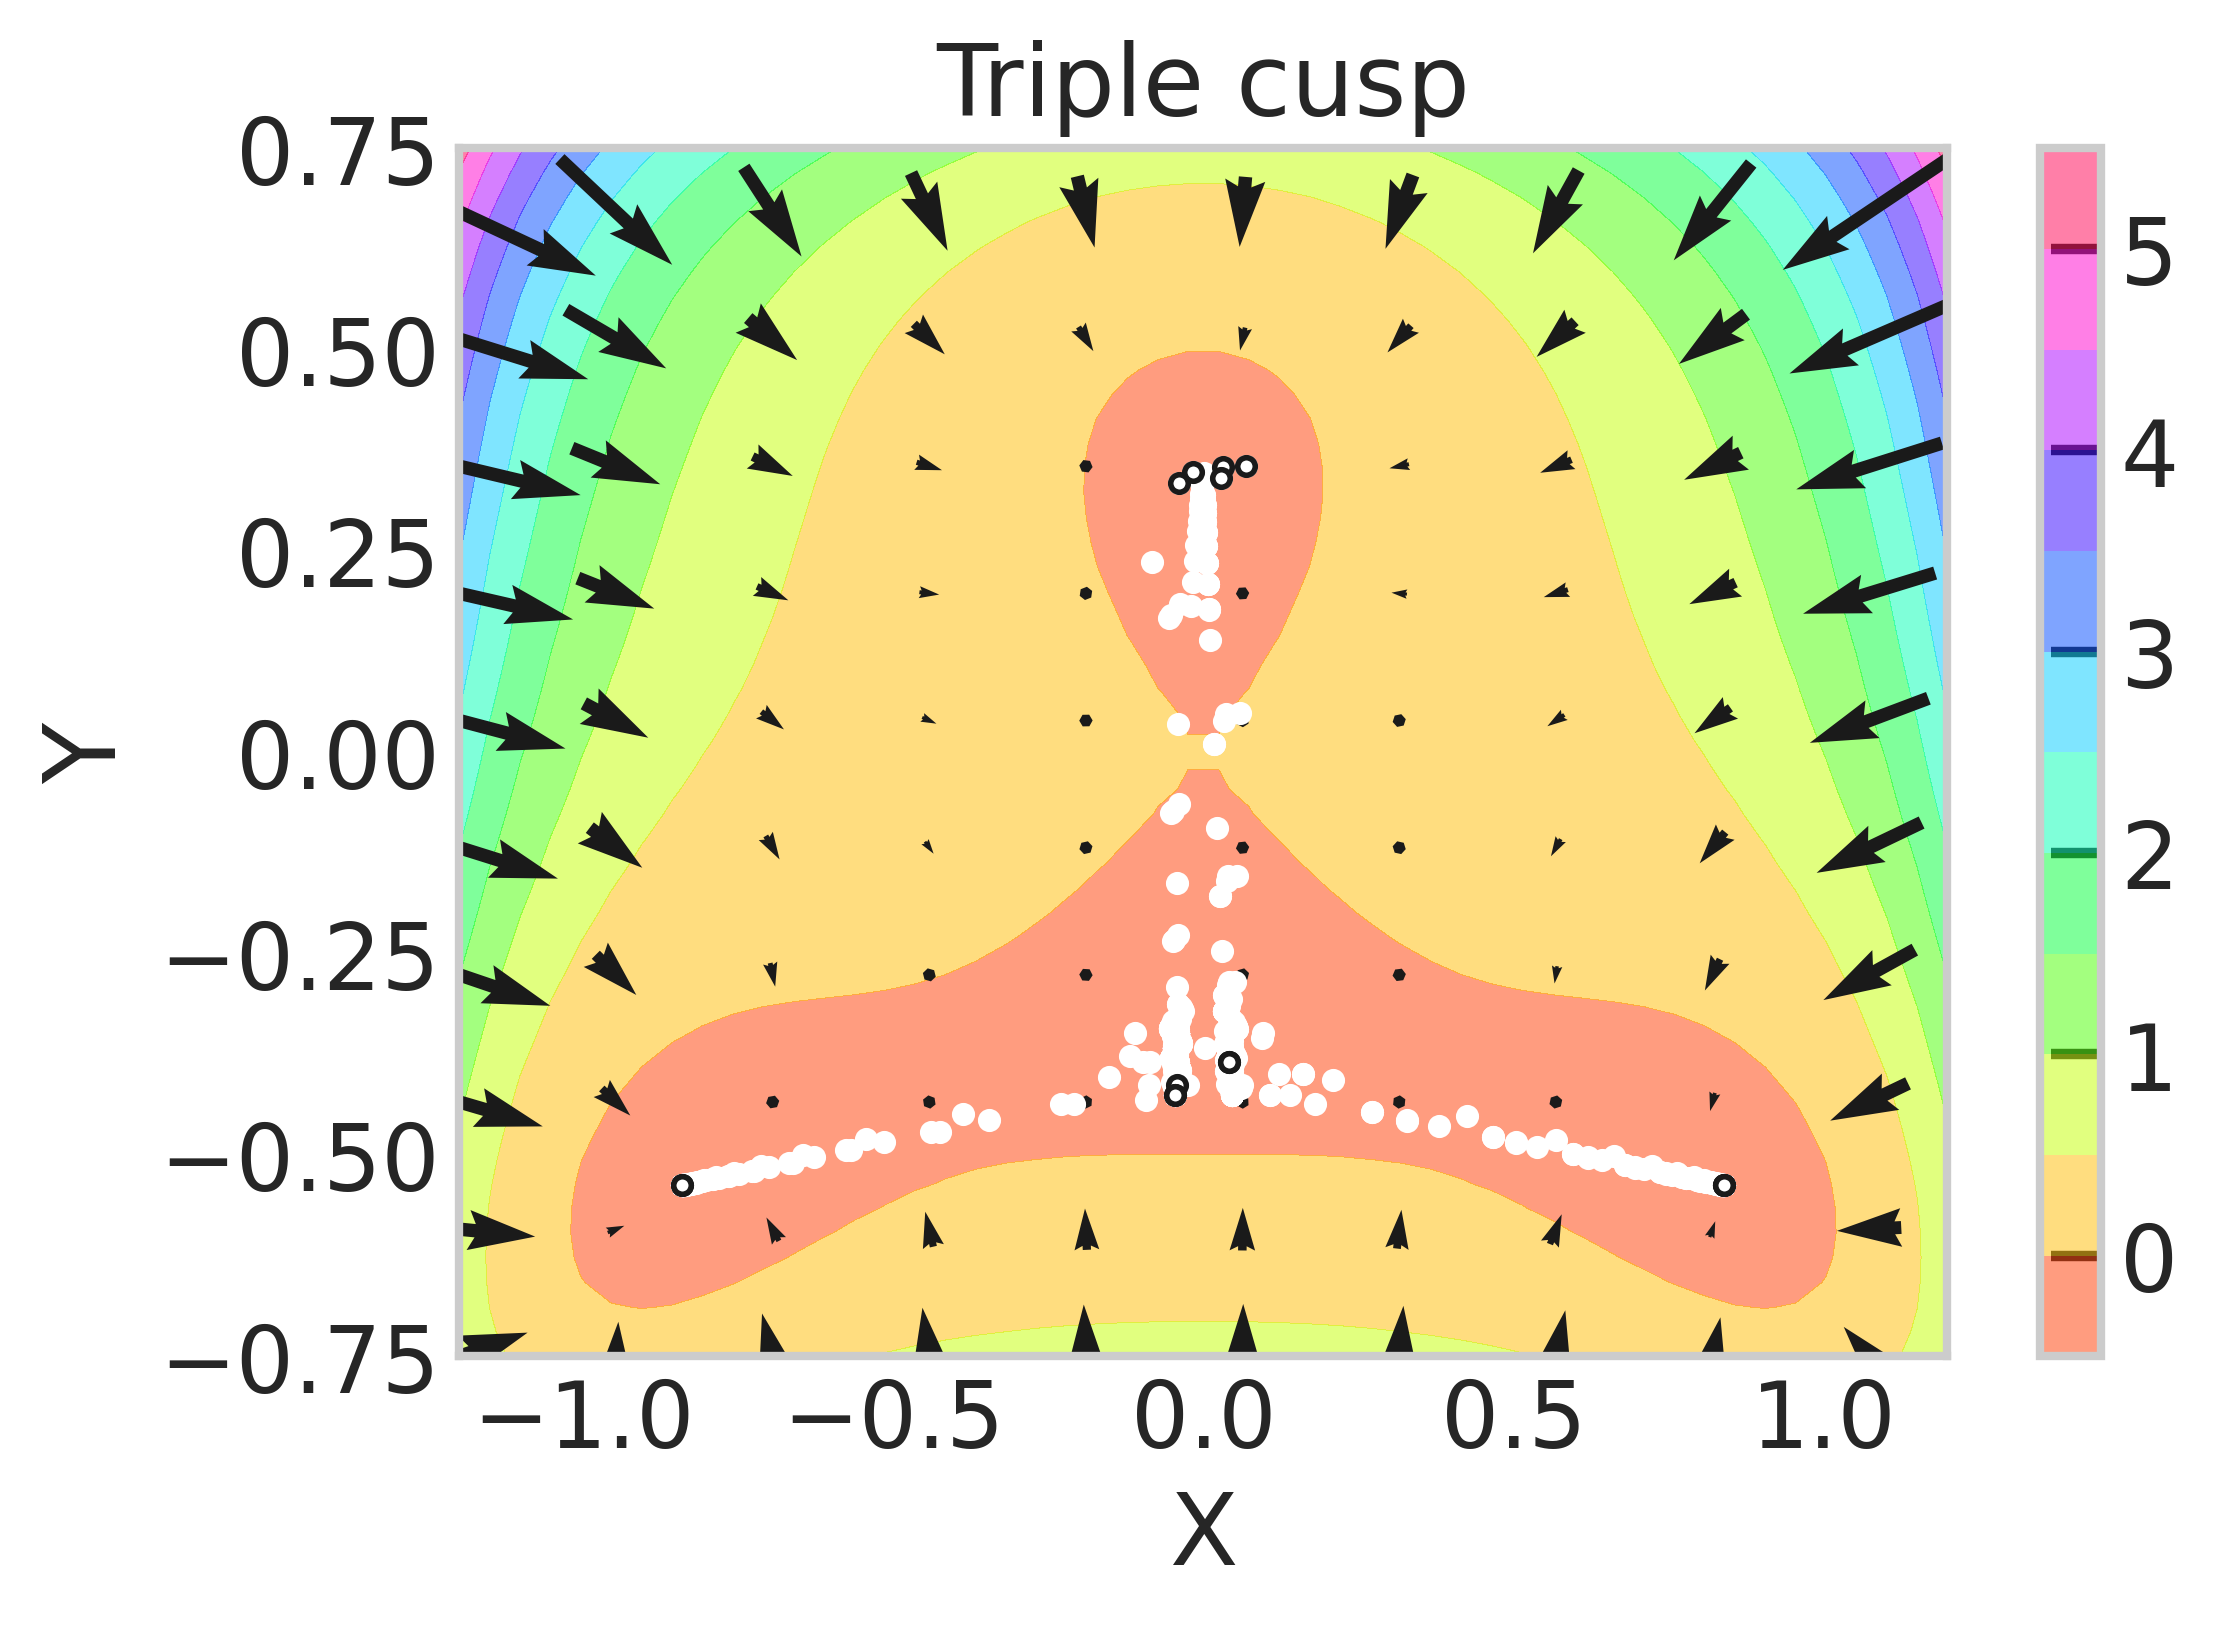

In [15]:
# plot the potential in x, y coords (can also plot as fn of m)

def potential_function(x, y, f, k):
    return x**6 - x**4 + x**2 + 4*y**4 - y**2 + 2*(x**2)*y + f*x + k*y

def potential_grad(x, y, f, k):
    grad_x = 6*x**5 - 4*x**3 + 2*x + 4*x*y + f
    grad_y = 16*y**3 - 2*y +2*x**2 + k
    return -grad_x, -grad_y

ylims = 0.75
time = 500

x = np.linspace(-1.2, 1.2, 50)
y = np.linspace(-ylims, ylims, 50)
X, Y = np.meshgrid(x, y)
f, k = 0, 0

Z = potential_function(X, Y, f, k)

plt.contourf(X, Y, Z, cmap="hsv", levels=10, alpha=0.5)
plt.colorbar()

x = np.linspace(-1.2, 1.2, 20)
y = np.linspace(-ylims, ylims, 20)
X, Y = np.meshgrid(x, y)

U, V = potential_grad(X, Y, f, k)
speed = np.sqrt(U**2 + V**2)

plt.quiver(X[::2, ::2], Y[::2, ::2], U[::2, ::2], V[::2, ::2],
           scale_units="inches", scale=20, width=0.009, pivot="mid")

df = all_output[['at1', 'at2', 'early epithelium']].T

ones_row = pd.DataFrame(np.ones((all_output.shape[0]))).T
ones_row.columns = df.columns
df = pd.concat([df, ones_row], axis=0)

X = np.dot(attractor_network.hx, df)
Y = np.dot(attractor_network.hy, df)

plt.scatter(x=X[::4], y=Y[::4], 
                s=10, color='white', zorder=3, linewidth=1)

plt.scatter(x=X[::time], y=Y[::time], 
                s=10, facecolors='white', edgecolor='k', zorder=3, linewidth=1)

plt.grid(False)

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Triple cusp')

plt.show()

# Plot dm/dt

In [184]:
attractor_states.mean(axis=1).sort_values(ascending=True).head(10)

Prr9      -0.943254
Gm16094   -0.943254
Bnc1      -0.943254
Gm16063   -0.943254
Gm16059   -0.943254
Gm16045   -0.943254
Gm16028   -0.943254
Gm16006   -0.943254
Gm15983   -0.943254
Boll      -0.943254
dtype: float64

In [ ]:
attractor_states.mean(axis=1).sort_values(ascending=True).head(10)

In [187]:
attractor_states.loc[genes_to_plot]

,at1,at2,early epithelium
Sftpc,3.056288,3.874800,1.965406
Aqp5,3.086170,2.313373,0.260080
Prr9,-0.930014,-1.212356,-0.687391
Bnc1,-0.930014,-1.212356,-0.687391


In [188]:
genes_to_plot = ['Sftpc', 'Prr9']

In [199]:
class AttractorNetworkPlot:
    """
    A class that simulates an attractor-based dynamical system with an evolving energy landscape.
    The system evolves toward stored attractor states under the influence of external gradients.
    """

    def __init__(self, dynamics_args, landscape_args):
        """
        Initialize the attractor network.

        Parameters:
        - dynamics_args: Dictionary containing 'stored_states' (matrix of gene expression profiles) and 'initial_state':
        
            dynamics_args = {
                'stored_states': attractor states stored as rows in a 2D array,
                'initial_state': the starting gene expression state (1D array)
            }
        
        - landscape_args: Dictionary containing 'start_params', 'attractor_coords', and 'gradients':
        
            landscape_args = {
                'start_params': dict of initial parameters for the energy landscape,
                'attractor_coords': coordinates for attractor projections in x-y space,
                'gradients': function returning gradients of the landscape w.r.t. x and y
            }
        
        """
        
        self.attractors = dynamics_args['stored_states'].copy()
        self.state = dynamics_args['initial_state'].copy()

        self.params = landscape_args['start_params'].copy()
        self.start_params = landscape_args['start_params']
        
        self.N = len(self.state)  # Number of elements in the state vector.
        self.temperature = 1 / (2 * self.N) # low temperature, so that there's not too much random jumping

        # Calculate the correlation matrix and its inverse.
        self.corr = (1 / self.N) * self.attractors.dot(self.attractors.T)
        self.inv_corr = np.linalg.inv(self.corr)

        # Unpack the attractor coordinates.
        self.x0, self.y0 = landscape_args['attractor_coords'][0]
        self.x1, self.y1 = landscape_args['attractor_coords'][1]
        
        self.x_hat = np.array([1, 0, 0, 0])
        self.y_hat = np.array([0, 1, 0, 0])
        
        x_to_m = generate_x_to_m_matrix(self.y0, self.x1, self.y1)
        self.m_to_x = np.linalg.inv(x_to_m)
        
        self.hx = np.dot(self.x_hat, self.m_to_x)
        self.hy = np.dot(self.y_hat, self.m_to_x)
        
        self.gradients = landscape_args['gradients']

        self.rng = np.random.default_rng()

        self.update_record = []

    def dx_dt(self, m_low):
        m_low_4d = np.array([*m_low, 1])
        
        x = np.dot(self.hx, m_low_4d)
        y = np.dot(self.hy, m_low_4d)
        
        inv_corr_4d = np.vstack((self.inv_corr, np.array([0, 0, 0])))
        inv_corr_4d = np.hstack((inv_corr_4d, np.array([0, 0, 0, 1]).reshape(-1, 1)))
        
        x_chain = np.dot(self.hx, inv_corr_4d)
        y_chain = np.dot(self.hy, inv_corr_4d)
        
        grad_x, grad_y = self.gradients(x, y, self.params)
        
        potential_grad = grad_x*x_chain + grad_y*y_chain
        potential_grad = potential_grad[:3]
        
        gradient_scale = 10 # adjustment factor to increase effect of gradient

        # attraction = self.attractors.T.dot(
        #     softmax((1/self.temperature)*(m_low - gradient_scale*potential_grad))
        # )

        attraction = self.attractors.T.dot(-1*potential_grad)

        return attraction #- self.state
        
    def dynamics(self, add_to_record):
        """
        Compute the change in the system's state based on attractor dynamics
        and the gradient of the external potential landscape.
        
        Returns:
        - A vector representing the change in state.
        """
        
        # NOTE: THESE ARE ACTUALLY FLIPPED FROM PAPER NOTATION!

        m_up = (1/self.N)*self.attractors.dot(self.state) # upper index/contravariant
        m_low = self.inv_corr.dot(m_up) # lower index/covariant

        derivative = self.dx_dt(m_low)

        if add_to_record:
            # record gradient from [-0.05, 1.05] in m0, m1, m2 space
            lim = (-0.05, 1.05)
            grid_n = 30
            m0_vals = np.linspace(*lim, grid_n)
            m1_vals = np.linspace(*lim, grid_n)
            m2_vals = np.linspace(*lim, grid_n)
            
            m0_sim = m_low[2].copy()
            m1_sim = m_low[0].copy()
            m2_sim = m_low[1].copy()

            # plot a: hold m0 constant and find m1, m2
            M1a, M2a = np.meshgrid(m1_vals, m2_vals)
            DM1a = np.zeros_like(M1a, dtype=float)
            DM2a = np.zeros_like(M2a, dtype=float)

            # plot b: hold m1 constant and find m0, m2
            M0b, M2b = np.meshgrid(m0_vals, m2_vals)
            DM0b = np.zeros_like(M0b, dtype=float)
            DM2b = np.zeros_like(M2b, dtype=float)

            # plot c: hold m2 constant and find m0, m1
            M1c, M0c = np.meshgrid(m1_vals, m0_vals)
            DM0c = np.zeros_like(M0c, dtype=float)
            DM1c = np.zeros_like(M1c, dtype=float)

            for i in range(M1a.shape[0]):
                for j in range(M1a.shape[1]):
                    dmdt = self.inv_corr.dot((1/self.N)*self.attractors.dot(self.dx_dt(np.array([M1a[i, j], M2a[i, j], m0_sim]))))
                    DM1a[i, j], DM2a[i, j] = dmdt[0], dmdt[1]

                    dmdt = self.inv_corr.dot((1/self.N)*self.attractors.dot(self.dx_dt(np.array([m1_sim, M2b[i, j], M0b[i, j]]))))
                    DM0b[i, j], DM2b[i, j] = dmdt[2], dmdt[1]

                    dmdt = self.inv_corr.dot((1/self.N)*self.attractors.dot(self.dx_dt(np.array([M1c[i, j], m2_sim, M0c[i, j]]))))
                    DM0c[i, j], DM1c[i, j] = dmdt[2], dmdt[0]

            gene_lims = (-1, 4)
            gene1 = np.linspace(*gene_lims, grid_n)
            gene2 = np.linspace(*gene_lims, grid_n)
            gene_grid1, gene_grid2 = np.meshgrid(gene1, gene2)
            DX1 = np.zeros_like(gene_grid1, dtype=float)
            DX2 = np.zeros_like(gene_grid2, dtype=float)

            for i in range(gene_grid1.shape[0]):
                for j in range(gene_grid1.shape[1]):
                    state_vec = self.state.copy()
                    state_vec[genes_to_plot[0]] = gene_grid1[i, j]
                    state_vec[genes_to_plot[1]] = gene_grid2[i, j]
                    m_up_sim = (1/self.N)*self.attractors.dot(state_vec) # upper index/contravariant
                    m_low_sim = self.inv_corr.dot(m_up_sim) # lower index/covariant
                    dxdt = self.dx_dt(m_low_sim)
                    DX1[i, j], DX2[i, j] = dxdt[genes_to_plot[0]], dxdt[genes_to_plot[1]]
                
            return (derivative, ((DM1a, DM2a, M1a, M2a, m0_sim),
                                            (DM0b, DM2b, M0b, M2b, m1_sim),
                                            (DM0c, DM1c, M0c, M1c, m2_sim),
                                            (DX1, DX2, gene_grid1, gene_grid2, self.state[genes_to_plot])),
                                            )
        else:
            return (derivative, None)

        
    def update(self, add_to_record=False):
        """
        Perform a single update of the network state using synchronous or asynchronous dynamics.
        """
        current_dynamics = self.dynamics(add_to_record)

        # "asynchronous updates": randomly choose which genes to update each time
        timing_scale = 10
        asynch = self.rng.binomial(1, 1/timing_scale, size=N) # allow 1 in __ genes to update at each step
        self.state += asynch*current_dynamics[0]/20

        if add_to_record:
            self.update_record += [current_dynamics[1]]
        
        # synchronous updates: all genes update simultaneously
#         self.state += self.dynamics()/20

    def increment_param(self, t, param, signal_bounds, finish_params):
        """
        Increment a specific bifurcation parameter gradually between start and end times.

        Parameters:
        - t: Current simulation time.
        - param: Parameter name to increment (e.g., 'f', 'k').
        - signal_bounds: Dict with 'start' and 'end' times for each parameter.
        - finish_params: Dict of final target values for parameters.
        """
        
        if (t > signal_bounds['start'][param]) and (t < signal_bounds['end'][param]):
            self.params[param] += (finish_params[param] - self.start_params[param])/(signal_bounds['end'][param] - signal_bounds['start'][param])

    def simulate(self, total_time, signal_bounds, finish_params, recorded_genes = None, add_noise = False):
        """
        Run a full simulation of the network over time, tracking magnetizations and optionally individual genes.

        Parameters:
        - total_time: Duration of the simulation.
        - signal_bounds: Dict specifying start/end times for each parameter change.
        - finish_params: Dict of final values for changing parameters.
        - recorded_genes: List of gene names (indices) to record over time.
        - add_noise: If True, adds dropout and Gaussian noise to measurements.

        Returns:
        - A pandas DataFrame containing time series of order parameters, magnetizations, and recorded genes.
        """

        magnetizations = []

        gene_dict = {}
        if recorded_genes is not None:
            for gene in recorded_genes:
                gene_dict[gene] = []

        time_interval = 1     
        for t in trange(0, total_time, time_interval):
            # Choose which parameters to increment
            self.increment_param(t, 'f', signal_bounds, finish_params)
            self.increment_param(t, 'k', signal_bounds, finish_params)
            
            if add_noise: # this just adds noise to the observations, not to the system
                detection_rate = 0.4
                dropout = self.rng.binomial(1, detection_rate, size=N)
                zero_indices = np.where(dropout == 0)[0]
                
                dropout_state = self.state.T.copy()
                dropout_state.iloc[zero_indices] = -1
                
                noise = self.rng.standard_normal(size=N)
                
                magnetizations += [(1/N)*self.attractors.dot(dropout_state + noise)]
                
            else:
                magnetizations += [(1/N)*self.attractors.dot(self.state.T)]
                
            if recorded_genes is not None:
                for gene in recorded_genes:
                    gene_dict[gene] += [self.state.loc[gene]]

            add_to_record = False
            if t%50==0:
                add_to_record = True
            
            self.update(add_to_record)
                    
        magnetizations = pd.DataFrame(magnetizations)
        if len(magnetizations.columns[0]) < 2:
            magnetizations = pd.DataFrame(magnetizations, columns = ['m{}'.format(index) for index in range(self.attractors.shape[0])])
        order_params = self.inv_corr.dot(magnetizations.T)
        
        output_df = pd.concat([pd.DataFrame(order_params, index = magnetizations.columns).T, magnetizations, pd.DataFrame(gene_dict)], axis=1)

        if len(magnetizations.columns[0]) < 2:
            output_df = pd.concat([pd.DataFrame(order_params, index = ['a{}'.format(index) for index in range(self.attractors.shape[0])]).T,
                                magnetizations, pd.DataFrame(gene_dict)], axis=1)
        return output_df

In [200]:
init_state = attractor_states['early epithelium']

dynamics_args_single = {'stored_states': attractor_states.T,
                        'initial_state': init_state}
landscape_args_single = {'start_params': {'f': 0, 'k': 0},
                         'attractor_coords': [[0, triple_cusp_coords['y0']], [triple_cusp_coords['x1'], triple_cusp_coords['y1']]],
                         'gradients': triple_cusp_grad}

net = AttractorNetworkPlot(dynamics_args_single, landscape_args_single)
net.temperature = 1e-6  # near-zero temperature (deterministic limit)

# sim_time = 3000
# sim_run = net.simulate(total_time=sim_time,
#                        signal_bounds={'start': {'f':2000 , 'k': 500}, 'end': {'f': 2400, 'k': 900}},
#                        finish_params={'f': 0.3, 'k': 0.3},
#                        add_noise=False)

sim_time = 3000
sim_run = net.simulate(total_time=sim_time,
                       signal_bounds={'start': {'f':1600 , 'k': 200}, 'end': {'f': 2400, 'k': 800}},
                       finish_params={'f': 0.3, 'k': 0.5},
                       add_noise=False)

update_record = net.update_record

100%|██████████| 3000/3000 [04:41<00:00, 10.67it/s]


In [201]:
vmin = 0
vmax = 0

for t in range(len(update_record)):
    this_record = update_record[t]

    plot_a = this_record[0]
    plot_b = this_record[1]
    plot_c = this_record[2]

    DM1a, DM2a, M1a, M2a, m0_sim = plot_a
    DM0b, DM2b, M0b, M2b, m1_sim = plot_b
    DM0c, DM1c, M0c, M1c, m2_sim = plot_c    

    this_max = np.max([DM1a, DM2a, DM0b, DM2b, DM0c, DM1c])

    vmax = np.max([vmax, this_max])

In [216]:
# Static L-shaped triple streamplot (m1 vs m2 top-left, m1 vs m0 bottom-left, m2 vs m0 top-right)
# Arrows colored with 'flare', current time point plotted in black.

from matplotlib.gridspec import GridSpec
from matplotlib.cm import ScalarMappable

cmap_flare = sns.color_palette('flare', as_cmap=True)

xlim = (-1, 4)
ylim = (-1, 4)

def plot_l_shaped_streams_genes(t=0):
    this_record = update_record[t]

    DX1, DX2, gene_grid1, gene_grid2, genes_sim = this_record[3]

    fig = plt.figure(figsize=(6, 6))
    gs = GridSpec(1, 1, figure=fig)

    ax_a = fig.add_subplot(gs[0, 0]) 

    norm = mpl.colors.Normalize(vmin=0, vmax=1)
    kwargs = {'density': 1.2, 'linewidth': 1.2, 'cmap': cmap_flare, 'norm': norm, 'broken_streamlines': True}

    speed12 = np.hypot(DX1, DX2)
    strm12 = ax_a.streamplot(gene_grid1, gene_grid2, DX1, DX2, color=speed12, **kwargs)

    ax_a.contour(gene_grid1, gene_grid2, DX1, levels=[0], colors='gray', linewidths=2, linestyles='--')
    ax_a.contour(gene_grid1, gene_grid2, DX2, levels=[0], colors='gray', linewidths=2, linestyles='-')
    # ax_a.fill([0, 1, 0], [0, 0, 1], alpha=0.18, color='gray', ec='k')
    ax_a.scatter([genes_sim[0]], [genes_sim[1]], color='k', s=50, zorder=10)
    ax_a.set_xlabel('$m^1$'); ax_a.set_ylabel('$m^2$')
    ax_a.set_xlim(*xlim); ax_a.set_ylim(*ylim); ax_a.set_aspect('equal')
    ax_a.set_title('$m^1$ vs $m^2$')

    # Global colorbar placed in its own axis to the right (spaced away from panels)
    # vmax = max(np.nanmax(speed12), np.nanmax(speed10), np.nanmax(speed20))
    mappable = ScalarMappable(norm=plt.Normalize(vmin=vmin, vmax=1), cmap=cmap_flare)

    # Dedicated colorbar axis on the right of the figure
    cax = fig.add_axes([0.925, 0.15, 0.02, 0.7])
    cb = fig.colorbar(mappable, cax=cax, label='||dm/dt||')

    plt.suptitle(f'Time index t = {t} — m1={m1_sim:.3f}, m2={m2_sim:.3f}, m0={m0_sim:.3f}', fontsize=12)
    plt.tight_layout(rect=[0, 0, 0.9, 0.96])
    plt.show()

In [214]:
this_record = update_record[-1]

DX1, DX2, gene_grid1, gene_grid2, genes_sim = this_record[3]
genes_sim

Sftpc    3.029181
Prr9    -0.894861
Name: early epithelium, dtype: float64

In [219]:
gene_grid2

array([[-1.        , -1.        , -1.        , -1.        , -1.        ,
        -1.        , -1.        , -1.        , -1.        , -1.        ,
        -1.        , -1.        , -1.        , -1.        , -1.        ,
        -1.        , -1.        , -1.        , -1.        , -1.        ,
        -1.        , -1.        , -1.        , -1.        , -1.        ,
        -1.        , -1.        , -1.        , -1.        , -1.        ],
       [-0.82758621, -0.82758621, -0.82758621, -0.82758621, -0.82758621,
        -0.82758621, -0.82758621, -0.82758621, -0.82758621, -0.82758621,
        -0.82758621, -0.82758621, -0.82758621, -0.82758621, -0.82758621,
        -0.82758621, -0.82758621, -0.82758621, -0.82758621, -0.82758621,
        -0.82758621, -0.82758621, -0.82758621, -0.82758621, -0.82758621,
        -0.82758621, -0.82758621, -0.82758621, -0.82758621, -0.82758621],
       [-0.65517241, -0.65517241, -0.65517241, -0.65517241, -0.65517241,
        -0.65517241, -0.65517241, -0.65517241, -0

In [237]:
zeros = np.zeros_like(DX1)
low_array = np.where(np.logical_and(DX1>-0.001, DX1<0.001))
DX1[low_array]

array([ 0.00084612, -0.00086358,  0.00080557, -0.00090416,  0.00076502,
       -0.00094473,  0.00072447, -0.00098531,  0.00068392,  0.00064337,
        0.00060282])

In [232]:
low_array = np.where(np.logical_and(DX2>-0.01, DX2<0.01))
len(DX2[low_array])

225

In [238]:
np.min(DX2)

np.float64(-0.05508801558631968)

In [241]:
np.where(DX1 == np.min(np.abs(DX1)))

(array([18]), array([29]))

In [245]:
np.where(DX2 == -np.min(np.abs(DX2)))

(array([18]), array([29]))

In [261]:
gene_grid1[18,29-5:29+5]

array([3.13793103, 3.31034483, 3.48275862, 3.65517241, 3.82758621,
       4.        ])

In [270]:
DX1[18, 19:35]

array([0.05116477, 0.04610182, 0.04104038, 0.03598044, 0.03092199,
       0.02586505, 0.02080961, 0.01575566, 0.01070322, 0.00565227,
       0.00060282])

In [271]:
len(DX1[18,:])

30

In [274]:
def second_deriv(x, DX):
    d2x = np.zeros_like(x)
    for i in range(1, len(x)-1):
        d2x[i] = (DX[i+1] - DX[i-1])/(x[i+1] - x[i-1])
    return d2x

In [275]:
D2X_gene1 = second_deriv(gene_grid1[18,:], DX1[18,:])
D2X_gene2 = second_deriv(gene_grid2[:,29], DX2[:,29])

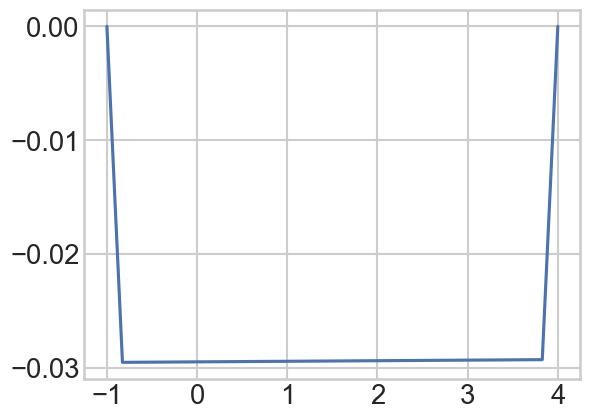

In [278]:
plt.plot(gene_grid1[18,:], D2X_gene1)

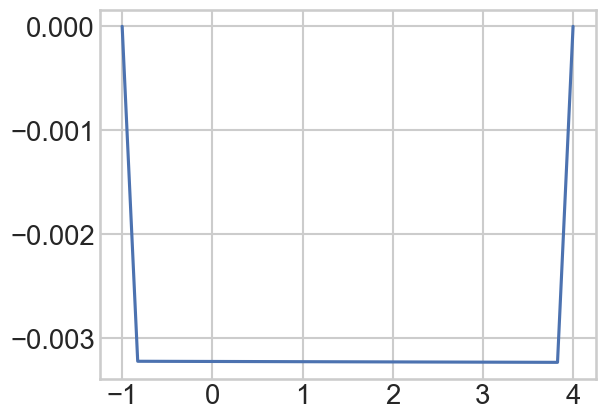

In [280]:
plt.plot(gene_grid2[:,29], D2X_gene2)

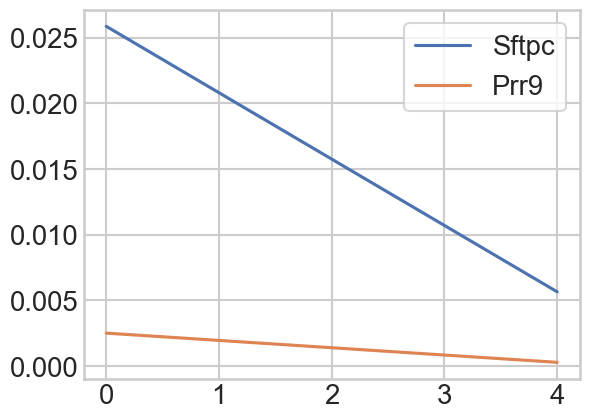

In [282]:
plt.plot(DX1[18, 29-5:29], label=genes_to_plot[0])
plt.plot(DX2[18-5:18, 29], label=genes_to_plot[1])
plt.legend()
plt.show()

In [283]:
approximate_slope_gene1 = (DX1[18, 29] - DX1[18, 24])/(gene_grid1[18, 29] - gene_grid1[18, 24])
approximate_slope_gene2 = (DX2[18, 29] - DX2[13, 29])/(gene_grid2[18, 29] - gene_grid2[13, 29])

In [284]:
gene_grid1[18, 29] - gene_grid1[18, 24]

np.float64(0.8620689655172411)

In [285]:
gene_grid2[18, 29] - gene_grid2[13, 29]

np.float64(0.8620689655172415)

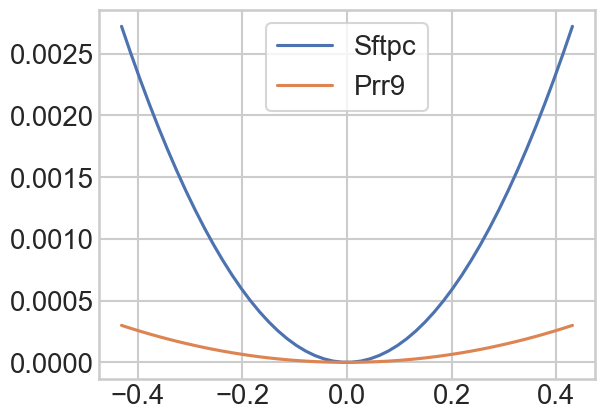

In [292]:
x = np.linspace(-0.5*(gene_grid2[18, 29] - gene_grid2[13, 29]), 0.5*(gene_grid2[18, 29] - gene_grid2[13, 29]))
plt.plot(x, -0.5*approximate_slope_gene1*x**2, label=genes_to_plot[0])
plt.plot(x, -0.5*approximate_slope_gene2*x**2, label=genes_to_plot[1])
plt.legend()
plt.show()

In [297]:
np.sqrt(1/np.abs(approximate_slope_gene1))

np.float64(5.841645258064334)

In [299]:
np.sqrt(1/np.abs(approximate_slope_gene2))/np.sqrt(1/np.abs(approximate_slope_gene1))

np.float64(3.014535191799884)

In [300]:
print(f"Approx ratio of sigma_1 to sigma_2 : {np.sqrt(np.abs(approximate_slope_gene1/approximate_slope_gene2))}")
print("actual std dev depends on diffusion constant (noise)")

Approx ratio of sigma_1 to sigma_2 : 3.014535191799884
actual std dev depends on diffusion constant (noise)


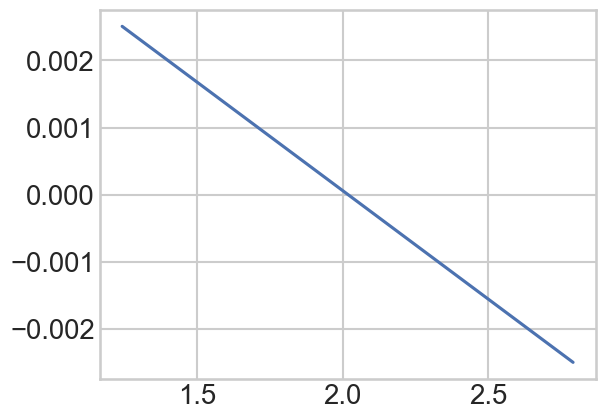

In [272]:
plt.plot(gene_grid2[18-5:18+5,29], DX2[18-5:18+5,29])

In [ ]:
adults = AT2_df.T[AT2_df.loc['day'] =='P42']
adults = adults.T.drop('day')
adults.std(axis=1)[['Sftpc', 'Bnc1', 'Gm16063', 'Gm16094']]

In [217]:
slider_l = IntSlider(min=0, max=len(update_record) - 1, step=1, value=0, description='t', continuous_update=False)
interact(plot_l_shaped_streams_genes, t=slider_l)

interactive(children=(IntSlider(value=0, continuous_update=False, description='t', max=59), Output()), _dom_cl…

<function __main__.plot_l_shaped_streams_genes(t=0)>

In [173]:
# Static L-shaped triple streamplot (m1 vs m2 top-left, m1 vs m0 bottom-left, m2 vs m0 top-right)
# Arrows colored with 'flare', current time point plotted in black.

from matplotlib.gridspec import GridSpec
from matplotlib.cm import ScalarMappable

cmap_flare = sns.color_palette('flare', as_cmap=True)

xlim = (-0.05, 1.05)
ylim = (-0.05, 1.05)

def plot_l_shaped_streams(t=0):
    this_record = update_record[t]

    plot_a = this_record[0]
    plot_b = this_record[1]
    plot_c = this_record[2]

    DM1a, DM2a, M1a, M2a, m0_sim = plot_a
    DM0b, DM2b, M0b, M2b, m1_sim = plot_b
    DM0c, DM1c, M0c, M1c, m2_sim = plot_c    

    fig = plt.figure(figsize=(10, 10))
    gs = GridSpec(2, 2, width_ratios=[1, 1], height_ratios=[1, 1], figure=fig)

    ax_a = fig.add_subplot(gs[0, 0])  # m1 vs m2 (top-left)
    ax_b = fig.add_subplot(gs[0, 1])  # m0 vs m2 (top-right)
    ax_c = fig.add_subplot(gs[1, 0])  # m1 vs m0 (bottom-left)
    ax_empty = fig.add_subplot(gs[1, 1])  # empty slot as spacer
    ax_empty.axis('off')

    # 1) m1 vs m2 (m0 fixed) — compute across the full [0,1]x[0,1] grid (no masking)
    # m1_vals = np.linspace(*xlim, grid_n)
    # m2_vals = np.linspace(*ylim, grid_n)
    # M1, M2 = np.meshgrid(m1_vals, m2_vals)
    # DM1 = np.zeros_like(M1, dtype=float)
    # DM2 = np.zeros_like(M2, dtype=float)

    # for i in range(M1.shape[0]):
    #     for j in range(M1.shape[1]):
    #         dmdt = compute_dmdt_full(m0_sim, M1[i, j], M2[i, j], stored_states, net.params)
    #         DM1[i, j], DM2[i, j] = dmdt[1], dmdt[2]

    norm = mpl.colors.Normalize(vmin=0, vmax=vmax)
    kwargs = {'density': 1.2, 'linewidth': 1.2, 'cmap': cmap_flare, 'norm': norm, 'broken_streamlines': True}

    speed12 = np.hypot(DM1a, DM2a)
    strm12 = ax_a.streamplot(M1a, M2a, DM1a, DM2a, color=speed12, **kwargs)

    ax_a.contour(M1a, M2a, DM1a, levels=[0], colors='gray', linewidths=2, linestyles='--')
    ax_a.contour(M1a, M2a, DM2a, levels=[0], colors='gray', linewidths=2, linestyles='-')
    # ax_a.fill([0, 1, 0], [0, 0, 1], alpha=0.18, color='gray', ec='k')
    ax_a.scatter([m1_sim], [m2_sim], color='k', s=50, zorder=10)
    ax_a.set_xlabel('$m^1$'); ax_a.set_ylabel('$m^2$')
    ax_a.set_xlim(*xlim); ax_a.set_ylim(*ylim); ax_a.set_aspect('equal')
    ax_a.set_title('$m^1$ vs $m^2$')

    # 2) m1 vs m0 (m2 fixed) -- x=m1, y=m0 (now bottom-left)
    # m1_vals = np.linspace(*xlim, grid_n)
    # m0_vals = np.linspace(*ylim, grid_n)
    # M1b, M0b = np.meshgrid(m1_vals, m0_vals)
    # DM1b = np.zeros_like(M1b, dtype=float)
    # DM0b = np.zeros_like(M0b, dtype=float)

    # for i in range(M1b.shape[0]):
    #     for j in range(M1b.shape[1]):
    #         dmdt = compute_dmdt_full(M0b[i, j], M1b[i, j], m2_sim, stored_states, net.params)
    #         DM1b[i, j], DM0b[i, j] = dmdt[1], dmdt[0]

    speed10 = np.hypot(DM0b, DM2b)
    strm10 = ax_b.streamplot(M0b, M2b, DM0b, DM2b, color=speed10, **kwargs)
    
    ax_b.contour(M0b, M2b, DM0b, levels=[0], colors='gray', linewidths=2, linestyles='--')
    ax_b.contour(M0b, M2b, DM2b, levels=[0], colors='gray', linewidths=2, linestyles='-')

    # ax_b.fill([0, 1, 0], [0, 0, 1], alpha=0.18, color='gray', ec='k')
    ax_b.scatter([m0_sim], [m2_sim], color='k', s=50, zorder=10)
    ax_b.set_xlabel('$m^1$'); ax_b.set_ylabel('$m^0$')
    ax_b.set_xlim(*xlim); ax_b.set_ylim(*ylim); ax_b.set_aspect('equal')
    ax_b.set_title('$m^0$ vs $m^2$')

    # 3) m2 vs m0 (m1 fixed) -- x=m0, y=m2 per request (now top-right)
    # m0_vals = np.linspace(*ylim, grid_n)
    # m2_vals = np.linspace(*ylim, grid_n)
    # M0c, M2c = np.meshgrid(m0_vals, m2_vals)  # x=M0c, y=M2c
    # DM0c = np.zeros_like(M0c, dtype=float)
    # DM2c = np.zeros_like(M2c, dtype=float)

    # for i in range(M0c.shape[0]):
    #     for j in range(M0c.shape[1]):
    #         dmdt = compute_dmdt_full(M0c[i, j], m1_sim, M2c[i, j], stored_states, net.params)
    #         DM0c[i, j], DM2c[i, j] = dmdt[0], dmdt[2]

    speed20 = np.hypot(DM1c, DM0c)
    strm20 = ax_c.streamplot(M1c, M0c, DM1c, DM0c, color=speed20, **kwargs)

    ax_c.contour(M1c, M0c, DM1c, levels=[0], colors='gray', linewidths=2, linestyles='--')
    ax_c.contour(M1c, M0c, DM0c, levels=[0], colors='gray', linewidths=2, linestyles='-')

    # ax_c.fill([0, 1, 0], [0, 0, 1], alpha=0.18, color='gray', ec='k')
    ax_c.scatter([m1_sim], [m0_sim], color='k', s=50, zorder=10)
    ax_c.set_xlabel('$m^0$'); ax_c.set_ylabel('$m^2$')
    ax_c.set_xlim(*xlim); ax_c.set_ylim(*ylim); ax_c.set_aspect('equal')
    ax_c.set_title('$m^1$ vs $m^0$')

    # Global colorbar placed in its own axis to the right (spaced away from panels)
    # vmax = max(np.nanmax(speed12), np.nanmax(speed10), np.nanmax(speed20))
    mappable = ScalarMappable(norm=plt.Normalize(vmin=vmin, vmax=vmax), cmap=cmap_flare)

    # Dedicated colorbar axis on the right of the figure
    cax = fig.add_axes([0.925, 0.15, 0.02, 0.7])
    cb = fig.colorbar(mappable, cax=cax, label='||dm/dt||')

    plt.suptitle(f'Time index t = {t} — m1={m1_sim:.3f}, m2={m2_sim:.3f}, m0={m0_sim:.3f}', fontsize=12)
    plt.tight_layout(rect=[0, 0, 0.9, 0.96])
    plt.show()

In [174]:
# Add an interactive slider tied to the L-shaped plot
from ipywidgets import interact, IntSlider, fixed

slider_l = IntSlider(min=0, max=len(update_record) - 1, step=1, value=0, description='t', continuous_update=False)
interact(plot_l_shaped_streams, t=slider_l)

interactive(children=(IntSlider(value=0, continuous_update=False, description='t', max=59), Output()), _dom_cl…

<function __main__.plot_l_shaped_streams(t=0)>

In [49]:
# Create an animation of the L-shaped view (HTML5 or MP4)
# Uses xlim/ylim, no gray triangle, colorbar in its own axis

from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import HTML as IPHTML, Video as IPVideo

# Animation builder
def make_l_shaped_animation(sim_run, grid_n=30, interval=200, frames=None, start=0, stop=None,
                             precompute=False, save_mp4=False, mp4_path='l_shaped_animation.mp4', dpi=150,
                             show_progress=True):
    """Build an animation of the L-shaped view.

    Key additions:
    - `frames` controls how many subsampled frames to render (evenly sampled across [start, stop)).
    - `precompute=True` will compute full vector fields (DM arrays) ahead of time -- this preserves streamplots and
      speeds for fast playback and is required for MP4 saving.
    - `save_mp4=True` writes an mp4 to `mp4_path` using FFMpegWriter; a tqdm progress bar is shown during saving.

    Returns HTML animation (JS) unless `save_mp4=True` in which case an IPython Video object is returned.
    """

    stop = len(sim_run) if stop is None else stop

    # Determine number of frames and precompute sampling indices (even subsampling)
    if frames is None:
        frames = int(stop - start)
    else:
        frames = int(frames)
        if frames <= 0:
            raise ValueError("frames must be a positive integer")

    indices = np.linspace(start, stop - 1, num=frames, dtype=int)

    # If mp4 requested but ffmpeg isn't available, warn and fall back to JS animation
    if save_mp4 and not shutil.which('ffmpeg'):
        warnings.warn(
            "ffmpeg not found in PATH; cannot save MP4. Falling back to JS animation. "
            "Install ffmpeg (e.g., `brew install ffmpeg`) to enable mp4 saving.")
        save_mp4 = False

    # Precompute meshes
    m_vals = np.linspace(*xlim, grid_n)

    M1, M2 = np.meshgrid(m_vals, m_vals)
    M1b, M0b = np.meshgrid(m_vals, m_vals)
    M0c, M2c = np.meshgrid(m_vals, m_vals)

    fig = plt.figure(figsize=(10, 10))
    gs = GridSpec(2, 2, width_ratios=[1, 1], height_ratios=[1, 1], figure=fig)

    ax_a = fig.add_subplot(gs[0, 0])  # m1 vs m2 (top-left)
    ax_b = fig.add_subplot(gs[1, 0])  # m1 vs m0 (bottom-left)
    ax_c = fig.add_subplot(gs[0, 1])  # m2 vs m0 (top-right)
    ax_empty = fig.add_subplot(gs[1, 1])
    ax_empty.axis('off')

    # Setup a ScalarMappable and colorbar axis (dedicated)
    mappable = ScalarMappable(cmap=cmap_flare)
    cax = fig.add_axes([0.925, 0.15, 0.02, 0.7])
    cb = fig.colorbar(mappable, cax=cax, label='||dm/dt||')

    # Helper: compute full vector fields + speeds for a single time index
    def compute_fields_for_t(t_index):
        m1_sim = float(_to_scalar(sim_run['at1'].iloc[t_index]))
        m2_sim = float(_to_scalar(sim_run['at2'].iloc[t_index]))
        m0_sim = float(_to_scalar(sim_run['early epithelium'].iloc[t_index]))

        # panel A: DM1, DM2
        DM1 = np.zeros_like(M1, dtype=float)
        DM2 = np.zeros_like(M2, dtype=float)
        for i in range(M1.shape[0]):
            for j in range(M1.shape[1]):
                dmdt = compute_dmdt_full(m0_sim, M1[i, j], M2[i, j], stored_states, net.params)
                DM1[i, j], DM2[i, j] = dmdt[1], dmdt[2]
        speed12 = np.hypot(DM1, DM2)

        # panel B: DM1b (x axis = m1), DM0b (y axis = m0)
        DM1b = np.zeros_like(M1b, dtype=float)
        DM0b = np.zeros_like(M0b, dtype=float)
        for i in range(M1b.shape[0]):
            for j in range(M1b.shape[1]):
                dmdt = compute_dmdt_full(M0b[i, j], M1b[i, j], m2_sim, stored_states, net.params)
                DM1b[i, j], DM0b[i, j] = dmdt[1], dmdt[0]
        speed10 = np.hypot(DM1b, DM0b)

        # panel C: DM0c (x axis = m0), DM2c (y axis = m2)
        DM0c = np.zeros_like(M0c, dtype=float)
        DM2c = np.zeros_like(M2c, dtype=float)
        for i in range(M0c.shape[0]):
            for j in range(M0c.shape[1]):
                dmdt = compute_dmdt_full(M0c[i, j], m1_sim, M2c[i, j], stored_states, net.params)
                DM0c[i, j], DM2c[i, j] = dmdt[0], dmdt[2]
        speed20 = np.hypot(DM0c, DM2c)

        return dict(DM1=DM1, DM2=DM2, speed12=speed12,
                    DM1b=DM1b, DM0b=DM0b, speed10=speed10,
                    DM0c=DM0c, DM2c=DM2c, speed20=speed20,
                    m1_sim=m1_sim, m2_sim=m2_sim, m0_sim=m0_sim)

    # Optionally precompute fields for sampled indices (useful for fast JS animation and required for MP4)
    precomputed = None
    if precompute or save_mp4:
        precomputed = {'DM1': [], 'DM2': [], 'speed12': [],
                       'DM1b': [], 'DM0b': [], 'speed10': [],
                       'DM0c': [], 'DM2c': [], 'speed20': [],
                       'm1': [], 'm2': [], 'm0': []}
        iterator = indices
        if show_progress:
            iterator = tqdm(indices, desc='Precomputing frames', ncols=80)
        for t in iterator:
            res = compute_fields_for_t(t)
            precomputed['DM1'].append(res['DM1'])
            precomputed['DM2'].append(res['DM2'])
            precomputed['speed12'].append(res['speed12'])

            precomputed['DM1b'].append(res['DM1b'])
            precomputed['DM0b'].append(res['DM0b'])
            precomputed['speed10'].append(res['speed10'])

            precomputed['DM0c'].append(res['DM0c'])
            precomputed['DM2c'].append(res['DM2c'])
            precomputed['speed20'].append(res['speed20'])

            precomputed['m1'].append(res['m1_sim'])
            precomputed['m2'].append(res['m2_sim'])
            precomputed['m0'].append(res['m0_sim'])

    # Update function: uses cached arrays if available
    def update(frame_index):
        # either map to full sim index via indices or use frame_index directly if frames==stop-start
        t = int(indices[frame_index])

        ax_a.clear(); ax_b.clear(); ax_c.clear()

        if precomputed is not None:
            DM1 = precomputed['DM1'][frame_index]
            DM2 = precomputed['DM2'][frame_index]
            speed12 = precomputed['speed12'][frame_index]

            DM1b = precomputed['DM1b'][frame_index]
            DM0b = precomputed['DM0b'][frame_index]
            speed10 = precomputed['speed10'][frame_index]

            DM0c = precomputed['DM0c'][frame_index]
            DM2c = precomputed['DM2c'][frame_index]
            speed20 = precomputed['speed20'][frame_index]

            m1_sim = precomputed['m1'][frame_index]
            m2_sim = precomputed['m2'][frame_index]
            m0_sim = precomputed['m0'][frame_index]

            # draw streamplots from cached vector fields
            ax_a.streamplot(M1, M2, DM1, DM2, color=speed12, density=1.2, linewidth=1.2, cmap=cmap_flare)
            ax_b.streamplot(M1b, M0b, DM1b, DM0b, color=speed10, density=1.2, linewidth=1.2, cmap=cmap_flare)
            ax_c.streamplot(M0c, M2c, DM0c, DM2c, color=speed20, density=1.2, linewidth=1.2, cmap=cmap_flare)

            ax_a.scatter([m1_sim], [m2_sim], color='k', s=50, zorder=10)
            ax_b.scatter([m1_sim], [m0_sim], color='k', s=50, zorder=10)
            ax_c.scatter([m0_sim], [m2_sim], color='k', s=50, zorder=10)

        else:
            # compute on the fly (slower)
            m1_sim = float(_to_scalar(sim_run['at1'].iloc[t]))
            m2_sim = float(_to_scalar(sim_run['at2'].iloc[t]))
            m0_sim = float(_to_scalar(sim_run['early epithelium'].iloc[t]))

            # panel A
            DM1 = np.zeros_like(M1, dtype=float)
            DM2 = np.zeros_like(M2, dtype=float)
            for i in range(M1.shape[0]):
                for j in range(M1.shape[1]):
                    dmdt = compute_dmdt_full(m0_sim, M1[i, j], M2[i, j], stored_states, net.params)
                    DM1[i, j], DM2[i, j] = dmdt[1], dmdt[2]
            ax_a.streamplot(M1, M2, DM1, DM2, color=np.hypot(DM1, DM2), density=1.2, linewidth=1.2, cmap=cmap_flare)

            # panel B
            DM1b = np.zeros_like(M1b, dtype=float)
            DM0b = np.zeros_like(M0b, dtype=float)
            for i in range(M1b.shape[0]):
                for j in range(M1b.shape[1]):
                    dmdt = compute_dmdt_full(M0b[i, j], M1b[i, j], m2_sim, stored_states, net.params)
                    DM1b[i, j], DM0b[i, j] = dmdt[1], dmdt[0]
            ax_b.streamplot(M1b, M0b, DM1b, DM0b, color=np.hypot(DM1b, DM0b), density=1.2, linewidth=1.2, cmap=cmap_flare)

            # panel C
            DM0c = np.zeros_like(M0c, dtype=float)
            DM2c = np.zeros_like(M2c, dtype=float)
            for i in range(M0c.shape[0]):
                for j in range(M0c.shape[1]):
                    dmdt = compute_dmdt_full(M0c[i, j], m1_sim, M2c[i, j], stored_states, net.params)
                    DM0c[i, j], DM2c[i, j] = dmdt[0], dmdt[2]
            ax_c.streamplot(M0c, M2c, DM0c, DM2c, color=np.hypot(DM0c, DM2c), density=1.2, linewidth=1.2, cmap=cmap_flare)

            ax_a.scatter([m1_sim], [m2_sim], color='k', s=50, zorder=10)
            ax_b.scatter([m1_sim], [m0_sim], color='k', s=50, zorder=10)
            ax_c.scatter([m0_sim], [m2_sim], color='k', s=50, zorder=10)

        # update colorbar range
        try:
            vmax = max(
                np.nanmax(precomputed['speed12'][frame_index]) if precomputed is not None else np.nanmax(np.hypot(DM1, DM2)),
                np.nanmax(precomputed['speed10'][frame_index]) if precomputed is not None else np.nanmax(np.hypot(DM1b, DM0b)),
                np.nanmax(precomputed['speed20'][frame_index]) if precomputed is not None else np.nanmax(np.hypot(DM0c, DM2c)),
                1e-8)
            mappable.set_norm(plt.Normalize(vmin=0, vmax=vmax))
            cb.update_normal(mappable)
        except Exception:
            pass

        ax_a.set_xlim(*xlim); ax_a.set_ylim(*ylim); ax_a.set_aspect('equal')
        ax_b.set_xlim(*xlim); ax_b.set_ylim(*ylim); ax_b.set_aspect('equal')
        ax_c.set_xlim(*xlim); ax_c.set_ylim(*ylim); ax_c.set_aspect('equal')

        plt.suptitle(f'Time index t = {t}', fontsize=12)
        return []

    # If user requested saving to MP4, ensure we have precomputed frames and then write using FFMpegWriter
    if save_mp4:
        if precomputed is None:
            # force precompute
            precomputed = {'DM1': [], 'DM2': [], 'speed12': [],
                           'DM1b': [], 'DM0b': [], 'speed10': [],
                           'DM0c': [], 'DM2c': [], 'speed20': [],
                           'm1': [], 'm2': [], 'm0': []}
            iterator = indices
            if show_progress:
                iterator = tqdm(indices, desc='Precomputing frames for MP4', ncols=80)
            for t in iterator:
                res = compute_fields_for_t(t)
                precomputed['DM1'].append(res['DM1'])
                precomputed['DM2'].append(res['DM2'])
                precomputed['speed12'].append(res['speed12'])

                precomputed['DM1b'].append(res['DM1b'])
                precomputed['DM0b'].append(res['DM0b'])
                precomputed['speed10'].append(res['speed10'])

                precomputed['DM0c'].append(res['DM0c'])
                precomputed['DM2c'].append(res['DM2c'])
                precomputed['speed20'].append(res['speed20'])

                precomputed['m1'].append(res['m1_sim'])
                precomputed['m2'].append(res['m2_sim'])
                precomputed['m0'].append(res['m0_sim'])

        fps = max(1, int(round(1000.0 / float(interval))))
        writer = FFMpegWriter(fps=fps)

        # final check (shouldn't happen because of earlier fallback)
        if not shutil.which('ffmpeg'):
            warnings.warn('ffmpeg not found in PATH; falling back to JS animation')
            ani = FuncAnimation(fig, update, frames=frames, interval=interval, blit=False)
            return IPHTML(ani.to_jshtml())

        # Use writer.saving and a progress bar
        with writer.saving(fig, mp4_path, dpi):
            range_iter = range(frames)
            if show_progress:
                range_iter = tqdm(range(frames), desc='Saving MP4 frames', ncols=80)
            for frame_index in range_iter:
                update(frame_index)
                writer.grab_frame()

        plt.close(fig)
        return IPVideo(mp4_path)

    # Otherwise return a JS HTML animation (fast playback in notebook)
    ani = FuncAnimation(fig, update, frames=frames, interval=interval, blit=False)

    return IPHTML(ani.to_jshtml())

In [50]:
make_l_shaped_animation(sim_run, save_mp4=True, mp4_path='triple_cusp_flow_animation_arrows.mp4', dpi=150, frames=100, precompute=True)

Saving MP4 frames: 100%|██████████████████████| 100/100 [00:47<00:00,  2.09it/s]



In [127]:
# Create an animation of the L-shaped view (HTML5 or MP4)
# Uses precomputed update_record[t], no gray triangle, colorbar in its own axis

from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import HTML as IPHTML, Video as IPVideo
from matplotlib.gridspec import GridSpec
from matplotlib.cm import ScalarMappable
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import shutil
import warnings
from tqdm import tqdm

# Plot preferences from first code
cmap_flare = sns.color_palette('flare', as_cmap=True)
xlim = (-0.05, 1.05)
ylim = (-0.05, 1.05)

def make_l_shaped_animation(update_record, frames=None, start=0, stop=None, interval=200,
                           save_mp4=False, mp4_path='l_shaped_animation.mp4', dpi=150,
                           show_progress=True):
    """
    Build an animation of the L-shaped view using precomputed update_record.
    
    - update_record[t] contains precomputed vector fields for time t
    - Each record[t] = [plot_a, plot_b, plot_c] where each plot is [DMx, DMy, Mx, My, m_fixed]
    - Returns HTML animation unless save_mp4=True (returns IPython Video)
    """
    stop = len(update_record) if stop is None else stop
    
    # Determine frames (even subsampling)
    if frames is None:
        frames = int(stop - start)
    else:
        frames = int(frames)
        if frames <= 0:
            raise ValueError("frames must be a positive integer")
    
    indices = np.linspace(start, stop - 1, num=frames, dtype=int)
    
    # Fallback if ffmpeg missing
    if save_mp4 and not shutil.which('ffmpeg'):
        warnings.warn("ffmpeg not found; falling back to JS animation.")
        save_mp4 = False
    
    fig = plt.figure(figsize=(10, 10))
    gs = GridSpec(2, 2, width_ratios=[1, 1], height_ratios=[1, 1], figure=fig)
    
    ax_a = fig.add_subplot(gs[0, 0])  # m1 vs m2 (top-left)
    ax_b = fig.add_subplot(gs[1, 0])  # m1 vs m0 (bottom-left) 
    ax_c = fig.add_subplot(gs[0, 1])  # m0 vs m2 (top-right)
    ax_empty = fig.add_subplot(gs[1, 1])
    ax_empty.axis('off')
    
    # Dedicated colorbar axis (same position as original)
    mappable = ScalarMappable(cmap=cmap_flare)
    cax = fig.add_axes([0.925, 0.15, 0.02, 0.7])
    cb = fig.colorbar(mappable, cax=cax, label='||dm/dt||')
    
    def update(frame_index):
        t = int(indices[frame_index])
        this_record = update_record[t]
        
        # Unpack precomputed data (same format as static plot_l_shaped_streams)
        plot_a = this_record[0]   # DM1a, DM2a, M1a, M2a, m0_sim
        plot_b = this_record[1]   # DM1b, DM0b, M1b, M0b, m2_sim  
        plot_c = this_record[2]   # DM0c, DM2c, M0c, M2c, m1_sim
        
        # DM1a, DM2a, M1a, M2a, m0_sim = plot_a
        # DM1b, DM0b, M1b, M0b, m2_sim = plot_b
        # DM0c, DM2c, M0c, M2c, m1_sim = plot_c

        DM1a, DM2a, M1a, M2a, m0_sim = plot_a
        DM0b, DM2b, M0b, M2b, m1_sim = plot_b
        DM0c, DM1c, M0c, M1c, m2_sim = plot_c    
        
        # Clear axes
        ax_a.clear(); ax_b.clear(); ax_c.clear()
        
        # Plot streamplots (same streamplot params as original animation)
        speed12 = np.hypot(DM1a, DM2a)
        ax_a.streamplot(M1a, M2a, DM1a, DM2a, color=speed12, density=1.2, 
                       linewidth=1.2, cmap=cmap_flare)
        ax_a.scatter([m1_sim], [m2_sim], color='k', s=50, zorder=10)
        
        speed10 = np.hypot(DM0b, DM2b)
        ax_b.streamplot(M0b, M2b, DM0b, DM2b, color=speed10, density=1.2, 
                       linewidth=1.2, cmap=cmap_flare)
        ax_b.scatter([m0_sim], [m2_sim], color='k', s=50, zorder=10)
        
        speed20 = np.hypot(DM1c, DM0c)
        ax_c.streamplot(M1c, M0c, DM1c, DM0c, color=speed20, density=1.2, 
                       linewidth=1.2, cmap=cmap_flare)
        ax_c.scatter([m0_sim], [m2_sim], color='k', s=50, zorder=10)
        
        # Dynamic colorbar (same logic as original)
        vmax_frame = max(np.nanmax(speed12), np.nanmax(speed10), np.nanmax(speed20), 1e-8)
        mappable.set_norm(plt.Normalize(vmin=0, vmax=vmax_frame))
        cb.update_normal(mappable)
        
        # Set limits and aspect (same as original)
        for ax in [ax_a, ax_b, ax_c]:
            ax.set_xlim(*xlim)
            ax.set_ylim(*ylim)
            ax.set_aspect('equal')
        
        plt.suptitle(f'Time index t = {t}', fontsize=12)
        return []
    
    # MP4 saving path
    if save_mp4:
        fps = max(1, int(round(1000.0 / float(interval))))
        writer = FFMpegWriter(fps=fps)
        
        with writer.saving(fig, mp4_path, dpi):
            range_iter = range(frames)
            if show_progress:
                range_iter = tqdm(range_iter, desc='Saving MP4 frames', ncols=80)
            for frame_index in range_iter:
                update(frame_index)
                writer.grab_frame()
        
        plt.close(fig)
        return IPVideo(mp4_path)
    
    # HTML5/JS animation (default)
    ani = FuncAnimation(fig, update, frames=frames, interval=interval, blit=False)
    return IPHTML(ani.to_jshtml())


In [129]:
make_l_shaped_animation(update_record, save_mp4=True, mp4_path='triple_cusp_flow_animation.mp4', dpi=150, frames=10, show_progress=True)

Saving MP4 frames: 100%|████████████████████████| 10/10 [00:04<00:00,  2.42it/s]
